# Tối ưu hoá log-loss — Santander Product Recommendation

Bài toán: hồi quy logistic dự đoán khách hàng **mua thêm** sản phẩm nào ở tháng $t$.

$$F(w)=\underbrace{\frac1n\sum_{i=1}^n\Big[\log\big(1+e^{z_i}\big)-y_iz_i\Big]}_{\text{log-loss}}
+\ \text{phần hiệu chỉnh},\qquad z=Xw$$

File này chỉ làm hai việc: **dựng ma trận đặc trưng** và **định nghĩa hai hàm mục tiêu**
(Ridge và Lasso). Các thuật toán tối ưu viết tiếp ở dưới.

In [1]:
import numpy as np
import pandas as pd

## 1. Đặc trưng — kiểu lời giải top Kaggle (160 đặc trưng + cột chặn)

Mỗi mẫu là một **tháng $t$** của một khách hàng, kèm **5 tháng trước đó** $(t-1,\dots,t-5)$:
đặc trưng lấy từ hồ sơ khách hàng và lịch sử sở hữu sản phẩm, nhãn là *"tháng $t$ có sản phẩm
mà tháng $t-1$ chưa có"*:

$$y_i=\mathbb{1}\big[\text{có ở }t\big]\cdot\mathbb{1}\big[\text{chưa có ở }t-1\big]$$

Bộ đặc trưng dựng theo hướng của các lời giải đứng đầu cuộc thi (hạng 1 idle_speculation,
hạng 2 Tom Van de Wiele): tín hiệu mạnh nhất là **lịch sử sở hữu sản phẩm qua nhiều tháng**,
không chỉ tháng liền trước.

| Nhóm | Số cột | Cột | Cách tính |
|---|---|---|---|
| chặn | 1 | `intercept` | cột toàn số 1, **không bị phạt** |
| số | 6 | `age`, `antiguedad`, `renta`, `ind_nuevo`, `ind_actividad_cliente`, `alta_year` | cắt ngưỡng cho hết ngoại lai; `renta` lấy $\log(1+x)$; `alta_year` = năm trong `fecha_alta`; thiếu thì điền trung vị |
| nhị phân | 7 | `sexo_V`, `seg_part`, `seg_univ`, `tiprel_I`, `kenh_KHE`, `kenh_KAT`, `kenh_KFC` | one-hot bỏ mức tham chiếu; kênh chỉ giữ 3 kênh phổ biến nhất |
| sở hữu $t-1$ | 24 | `ind_*_lag` | có sản phẩm đó ở tháng $t-1$ hay chưa (0/1) |
| sở hữu $t-2..t-5$ | 96 | `ind_*_lag2` … `ind_*_lag5` | như trên, lùi 2–5 tháng; khách chưa mở tài khoản ở tháng đó thì tính là chưa có |
| thời gian | 24 | `ind_*_thang` | số tháng kể từ lần gần nhất có sản phẩm đó (1–5; **6** = không có trong cả 5 tháng) |
| tổng hợp | 3 | `so_sp`, `doi_seg`, `doi_hd` | số sản phẩm đang có ở $t-1$; phân khúc / trạng thái hoạt động có đổi so với $t-1$ không |

Mọi cột đưa về cùng thang đo $\;(x-\mu)/\sigma$ (dùng $\mu,\sigma$ **của tập train**) để mọi
toạ độ có độ cong tương đương — nếu không, `renta` cỡ vạn còn cờ 0/1 cỡ 1 thì gradient descent
sẽ zig-zag rất lâu.

**Cỡ mẫu.** Giữ nguyên cách lấy mẫu cũ: **1/12 số khách** (lọc theo mã khách, cùng một tập khách
xuyên suốt mọi tháng), 13 tháng 2015-01 → 2016-01, validation là tháng 2016-01. Vì cần đủ 5
tháng lịch sử nên tháng mục tiêu của tập train bắt đầu từ 2015-06 (7 tháng thay vì 11) — ít
dòng hơn bản cũ.

In [2]:
SP = ["ind_ahor_fin_ult1", "ind_aval_fin_ult1", "ind_cco_fin_ult1", "ind_cder_fin_ult1",
      "ind_cno_fin_ult1", "ind_ctju_fin_ult1", "ind_ctma_fin_ult1", "ind_ctop_fin_ult1",
      "ind_ctpp_fin_ult1", "ind_deco_fin_ult1", "ind_deme_fin_ult1", "ind_dela_fin_ult1",
      "ind_ecue_fin_ult1", "ind_fond_fin_ult1", "ind_hip_fin_ult1", "ind_plan_fin_ult1",
      "ind_pres_fin_ult1", "ind_reca_fin_ult1", "ind_tjcr_fin_ult1", "ind_valo_fin_ult1",
      "ind_viv_fin_ult1", "ind_nomina_ult1", "ind_nom_pens_ult1", "ind_recibo_ult1"]
SO_LAG = 5                                       # so thang lich su cho moi san pham
LAG = [c + "_lag" for c in SP]                   # so huu o t-1 (giu ten cu)
LAG_K = [c + "_lag%d" % l for l in range(2, SO_LAG + 1) for c in SP]   # t-2 .. t-5
THANG_SP = [c + "_thang" for c in SP]            # so thang ke tu lan cuoi co san pham
KHAC = ["so_sp", "doi_seg", "doi_hd"]
SO  = ["age", "antiguedad", "renta", "ind_nuevo", "ind_actividad_cliente", "alta_year"]
NHI = ["sexo_V", "seg_part", "seg_univ", "tiprel_I", "kenh_KHE", "kenh_KAT", "kenh_KFC"]

THANG_ALL = (["2015-%02d-28" % m for m in range(1, 13)] +
             ["2016-%02d-28" % m for m in range(1, 6)])
THANG = THANG_ALL[:-4]      # k thang -> (k-2) cap train + 1 cap validation.
                            # 4 thang ~ 1.6 trieu dong ~ 750 MB dinh RAM.
                            # De ca THANG_ALL (17 thang) se HET RAM tren may nay.

MAU_MOD = 12    # giu CO DINH 1/MAU_MOD khach hang (loc theo ma khach % MAU_MOD == 0), cung
                # mot tap khach xuyen suot moi thang -> ghep t-1/t van khop. Van giu du ~1 nam
                # du lieu (13 thang), chi bot SO KHACH -> X_tr con ~8,09tr/12 ~ 674k dong
                # (thay vi 8,09tr) cho nhe RAM/thoi gian. MAU_MOD=1 = lay het, khong lay mau.

def lam_sach(c):
    """Loc thang can + LAY MAU CO DINH theo ma khach, ngay tren tung chunk, de khong bao gio
    ton tai ban `str` cua ca file (13.6 trieu dong x 36 cot -> vai GB)."""
    ma = pd.to_numeric(c["ncodpers"], errors="coerce")
    c = c[c["fecha_dato"].isin(THANG) & (ma % MAU_MOD == 0)].copy()
    c[SP] = c[SP].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.int8)
    c["age"]        = pd.to_numeric(c["age"], errors="coerce").clip(18, 95)
    c["antiguedad"] = pd.to_numeric(c["antiguedad"], errors="coerce").clip(0, 260)
    c["renta"]      = np.log1p(pd.to_numeric(c["renta"], errors="coerce").clip(0, 1.5e6))
    c["ind_nuevo"]  = pd.to_numeric(c["ind_nuevo"], errors="coerce")
    c["ind_actividad_cliente"] = pd.to_numeric(c["ind_actividad_cliente"], errors="coerce")
    c["alta_year"]  = pd.to_datetime(c["fecha_alta"], errors="coerce").dt.year
    c[SO] = c[SO].astype(np.float32)

    c["sexo_V"]   = (c["sexo"] == "V").astype(np.float32)
    c["seg_part"] = (c["segmento"] == "02 - PARTICULARES").astype(np.float32)
    c["seg_univ"] = (c["segmento"] == "03 - UNIVERSITARIO").astype(np.float32)
    c["tiprel_I"] = (c["tiprel_1mes"] == "I").astype(np.float32)
    c["kenh_KHE"] = (c["canal_entrada"] == "KHE").astype(np.float32)
    c["kenh_KAT"] = (c["canal_entrada"] == "KAT").astype(np.float32)
    c["kenh_KFC"] = (c["canal_entrada"] == "KFC").astype(np.float32)

    c["ncodpers"] = c["ncodpers"].astype(np.int32)          # ma khach: 4 byte thay vi chuoi
    return c[["fecha_dato", "ncodpers"] + SO + NHI + SP]    # vut cac cot goc dang chuoi

df = pd.concat([lam_sach(c) for c in pd.read_csv(
    "train_ver2.csv", chunksize=10**6, dtype=str,
    usecols=["fecha_dato", "ncodpers", "fecha_alta", "age", "antiguedad", "renta",
             "ind_nuevo", "ind_actividad_cliente", "sexo", "segmento", "tiprel_1mes",
             "canal_entrada"] + SP)], ignore_index=True)
df[SO] = df[SO].fillna(df[SO].median())     # trung vi phai tinh tren toan bo, nen de o day
print("df:", df.shape, "| RAM: %.0f MB" % (df.memory_usage(deep=True).sum() / 1e6))


COT = SO + NHI + LAG + LAG_K + THANG_SP + KHAC


def cap(i):
    """Thang t = THANG[i] ghep voi SO_LAG thang truoc -> X (chua chuan hoa), Y ("them moi", 24 cot).
    Khach phai co mat o t-1 (de dinh nghia "them moi"); t-2..t-5 chua mo tai khoan = chua so huu."""
    sau = df[df["fecha_dato"] == THANG[i]]
    t1 = df[df["fecha_dato"] == THANG[i - 1]][["ncodpers"] + SP + ["seg_part", "seg_univ",
                                                                  "ind_actividad_cliente"]]
    t1.columns = ["ncodpers"] + LAG + ["seg_part_1", "seg_univ_1", "hd_1"]
    m = sau.merge(t1, on="ncodpers")
    for l in range(2, SO_LAG + 1):
        tl = df[df["fecha_dato"] == THANG[i - l]][["ncodpers"] + SP]
        tl.columns = ["ncodpers"] + [c + "_lag%d" % l for c in SP]
        m = m.merge(tl, on="ncodpers", how="left")
    m[LAG_K] = m[LAG_K].fillna(0)

    so_huu = m[LAG + LAG_K].values.reshape(len(m), SO_LAG, 24)       # (khach, thang lui, san pham)
    them = pd.DataFrame(np.where(so_huu.any(1), so_huu.argmax(1) + 1, SO_LAG + 1),
                        columns=THANG_SP, index=m.index)
    them["so_sp"] = m[LAG].sum(1)
    them["doi_seg"] = ((m["seg_part"] != m["seg_part_1"]) | (m["seg_univ"] != m["seg_univ_1"])).astype(np.float32)
    them["doi_hd"] = (m["ind_actividad_cliente"] != m["hd_1"]).astype(np.float32)
    m = pd.concat([m, them], axis=1)       # ghep 1 lan; gan tung cot vao m -> pandas bao PerformanceWarning
    Y = (m[SP].values == 1) & (m[LAG].values == 0)
    return m[COT].values.astype(np.float32), Y.astype(np.float32)


# thang muc tieu phai co du SO_LAG thang truoc -> train tu THANG[SO_LAG], thang cuoi lam validation
Xs, Ys = zip(*[cap(i) for i in range(SO_LAG, len(THANG) - 1)])
X_tr, Y_tr = np.vstack(Xs), np.vstack(Ys)
X_va, Y_va = cap(len(THANG) - 1)
tk = pd.DataFrame(np.vstack(Xs), columns=COT).describe().T.round(3)
del Xs, Ys, df                                  # bo ban sao va bang str, doi lai kha nhieu RAM

mu, sd = X_tr.mean(0), X_tr.std(0)
sd[sd < 1e-12] = 1.0
X_tr = np.c_[np.ones(len(X_tr), np.float32), (X_tr - mu) / sd]    # cot 0 = intercept
X_va = np.c_[np.ones(len(X_va), np.float32), (X_va - mu) / sd]
TEN = ["intercept"] + COT

k = SP.index("ind_recibo_ult1")                 # san pham co ti le mua cao nhat
y_tr, y_va = Y_tr[:, k].astype(np.float64), Y_va[:, k].astype(np.float64)
X_tr, X_va = X_tr.astype(np.float64), X_va.astype(np.float64)
n, d = X_tr.shape
print("X_tr:", X_tr.shape, " X_va:", X_va.shape,
      " ti le duong: train %.2f%%  valid %.2f%%" % (y_tr.mean() * 100, y_va.mean() * 100))

df: (829699, 39) | RAM: 122 MB


X_tr: (466243, 161)  X_va: (75839, 161)  ti le duong: train 1.22%  valid 1.07%


In [3]:

THANG_ALL = (["2015-%02d-28" % m for m in range(1, 13)] +
             ["2016-%02d-28" % m for m in range(1, 6)])
THANG = THANG_ALL[:-4]  
THANG

['2015-01-28',
 '2015-02-28',
 '2015-03-28',
 '2015-04-28',
 '2015-05-28',
 '2015-06-28',
 '2015-07-28',
 '2015-08-28',
 '2015-09-28',
 '2015-10-28',
 '2015-11-28',
 '2015-12-28',
 '2016-01-28']

## 2. Hai hàm mục tiêu

Cùng một log-loss, khác nhau ở phần hiệu chỉnh:

$$\text{Ridge}\quad F(w)=\ell(w)+\frac{\lambda}{2}\|w\|_2^2
\qquad\qquad
\text{Lasso}\quad F(w)=\ell(w)+\lambda\|w\|_1$$

Cả hai hàm trả về **cặp `(F, g)`** — giá trị hàm mục tiêu và gradient — vì mọi thuật toán
đều cần cả hai ở cùng một điểm $w$, tính chung một lượt thì đỡ nhân ma trận hai lần.

$$\ell(w)=\frac1n\sum_i\big[\log(1+e^{z_i})-y_iz_i\big],
\qquad \nabla\ell(w)=\frac1nX^\top\big(\sigma(Xw)-y\big)$$

Khác biệt quan trọng: **Ridge trơn** nên `g` là gradient thật của cả $F$ → dùng thẳng cho
GD/SGD. **Lasso gãy tại 0** nên `g` chỉ là gradient của phần trơn $\ell$; phần $\lambda\|w\|_1$
phải tự xử lý bằng subgradient hoặc toán tử prox.

Cột `intercept` **không bị phạt** (chỉ số 0 bị loại khỏi cả hai phần hiệu chỉnh): hệ số chặn
chỉ dịch mức nền của xác suất, ép nó về 0 là ép mô hình tin tỉ lệ mua bằng 50%.

In [4]:
def sigmoid(z):
    """1/(1+e^-z), tinh theo hai nhanh de e^|z| khong tran so."""
    duong = z >= 0
    out = np.empty_like(z)
    out[duong] = 1.0 / (1.0 + np.exp(-z[duong]))
    e = np.exp(z[~duong])
    out[~duong] = e / (1.0 + e)
    return out


def ridge(w, X, y, lam):
    """F = log-loss + (lam/2)||w||^2. Tra ve (F, gradient cua F) — F tron moi noi."""
    z = X @ w
    F = np.mean(np.logaddexp(0, z) - y * z) + 0.5 * lam * np.sum(w[1:] ** 2)
    g = X.T @ (sigmoid(z) - y) / len(y)
    g[1:] += lam * w[1:]
    return F, g


def lasso(w, X, y, lam):
    """F = log-loss + lam*||w||_1. Tra ve (F, gradient cua RIENG phan log-loss),
    vi ||w||_1 khong kha vi tai 0 — phan do xu ly bang subgradient hoac prox."""
    z = X @ w
    F = np.mean(np.logaddexp(0, z) - y * z) + lam * np.sum(np.abs(w[1:]))
    g = X.T @ (sigmoid(z) - y) / len(y)
    return F, g

Vài công thức cần đến khi viết thuật toán:

- **Hằng số Lipschitz** của $\nabla\ell$: $L=\dfrac{\sigma_{\max}(X)^2}{4n}+\lambda$
  (vì $\sigma'(z)\le\frac14$) → bước cố định an toàn $t=1/L$.
- **Hessian** (cần cho Newton, chỉ có ở Ridge vì Lasso không khả vi hai lần):
  $\nabla^2F(w)=\frac1nX^\top\mathrm{diag}\big(\sigma_i(1-\sigma_i)\big)X+\lambda I$
  — code gọn là `X.T @ (X * s[:, None]) / n` với `s = sig * (1 - sig)`.
- **Subgradient của $\lambda|w_j|$**: bằng $\lambda\,\mathrm{sign}(w_j)$ nếu $w_j\neq0$,
  và là cả đoạn $[-\lambda,\lambda]$ nếu $w_j=0$.
- **Prox của $\lambda\|\cdot\|_1$** (soft-threshold):
  $\mathrm{prox}_{t\lambda}(v)_j=\mathrm{sign}(v_j)\max(|v_j|-t\lambda,\,0)$.

---

## 3. Thuật toán

Đề bài yêu cầu, để tự đối chiếu khi viết tiếp:

- [ ] **GD**, **SGD**, **accelerated GD**, **Newton** — mỗi thuật toán chạy được cả
      **bước cố định** lẫn **backtracking**. (Có thành phần Ridge/Lasso là điểm cộng →
      thêm **subgradient** và **proximal** cho Lasso.)
- [ ] Mỗi thuật toán thử **nhiều tham số/độ dài bước**, rút ra kinh nghiệm chọn tham số.
- [ ] So sánh các thuật toán với nhau, mỗi thuật toán dùng **setup tốt nhất** tìm được ở trên.
- [ ] Mỗi so sánh vẽ **hai hình riêng**: trục tung là $F(w)$, trục hoành lần lượt là
      **số vòng lặp** và **thời gian chạy**.
- [ ] So với **sklearn ở chế độ mặc định**: so **giá trị hàm mục tiêu** và **thời gian tính**
      (không phải độ chính xác). Lưu ý sklearn tối thiểu hoá
      $\frac12\|w\|^2+C\sum_i\ell_i$ (tổng, không phải trung bình) nên muốn so cùng một hàm
      thì đặt $\lambda=\dfrac{1}{C\,n}$ rồi quy về cùng thang.

In [5]:
import time

def gradient_descent(X, y, lam, buoc, so_vong=1000):
    """GD buoc co dinh tren bai toan Ridge.
    Tra ve w cuoi cung + lich su F va thoi gian (giu NGUYEN ca doan phan ky,
    vi doan vot len chinh la bang chung 'buoc qua lon' can dua vao bao cao)."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    t0 = time.time()
    for i in range(so_vong):
        F, g = ridge(w, X, y, lam)      # lam vao thang trong gradient
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):          # buoc qua lon -> tran so, dung han
            break
        w -= buoc * g
    return w, F_list, t_list


# Hang so Lipschitz cua phan log-loss: L = sigma_max(X)^2/(4n), vi sigma'(z) <= 1/4.
# d ~ 160 nho nen tinh thang tri rieng cua X^T X / n, khong can power iteration.
L0 = np.linalg.eigvalsh(X_tr.T @ X_tr / n).max() / 4
print("L = %.4f   ->   buoc an toan 1/L = %.4f" % (L0, 1 / L0))

L = 6.2508   ->   buoc an toan 1/L = 0.1600

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# RAMP: mot hue nhat -> dam, cho tham so CO THU TU (do dai buoc, alpha0, beta, lich giam buoc).
# MAU_TT: moi THUAT TOAN mot mau CO DINH, dung y het o moi hinh so sanh.
RAMP = ["#ef8f52", "#d96a24", "#ac4d15", "#7d360e", "#4f2107", "#2b1003"]     # ordinal, hue cam
MAU_TT = {"GD bước cố định": "#2a78d6", "GD backtracking": "#eb6834",
          "GD Nesterov": "#4a3aa7", "Newton": "#c026d3", "SGD": "#eda100",
          "Subgradient": "#d6336c", "Proximal": "#7f6b00", "sklearn": "#1baf7a"}
MUC, PHU, MO, LUOI, NEN = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
NET = 1.0        # do day net ve, dung chung cho moi hinh
HINH = "overleaf/hinh/"   # moi hinh luu thang vao day -> slide dung luon, khong phai chep tay


def diem_phang(F, nguong=0.995):
    """Vi tri ma duong da di duoc `nguong` phan muc giam cua no. Dung de cat phan duoi
    nam ngang: ve 250 vong trong khi vong 20 da cham day thi 92% khung hinh la duong thang."""
    F = np.asarray(F)
    F = F[np.isfinite(F)]
    if len(F) < 3 or F[0] <= F.min():
        return len(F)
    da_di = (F[0] - F) / (F[0] - F.min())
    return int(np.argmax(da_di >= nguong)) + 1


def chu_giai(ax, muc):
    """Legend dung chung cho MOI hinh: moi muc la mot o vuong mau + ten,
    cung co chu, cung vi tri (ben phai khung hinh)."""
    o_vuong = [Line2D([], [], ls="", marker="s", ms=8, color=c) for _, c in muc]
    ax.legend(o_vuong, [ten for ten, _ in muc], loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=10, labelcolor=PHU, handletextpad=0.4)


def trang_tri(ax, ten_x, ten_y, tieu_de):
    ax.set_xlabel(ten_x, color=PHU, fontsize=12)
    ax.set_ylabel(ten_y, color=PHU, fontsize=12)
    ax.set_title(tieu_de, color=MUC, fontsize=12, loc="left")
    ax.grid(True, color=LUOI, lw=0.6)
    ax.set_axisbelow(True)
    for canh in ("top", "right", "left"):
        ax.spines[canh].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=MO, length=0, labelsize=11)


def ve(duong, theo_thoi_gian=True, log_x=False, log_y=False, tieu_de="",
       mau=RAMP, moc=None, luu=None, ten_x=None, chia_x=1, cat=1.6):
    """duong: list cac bo (nhan, F_list, t_list), moi bo mot duong.
    theo_thoi_gian=False -> truc hoanh la so vong lap (chia cho chia_x neu doi don vi);
    chia_x la list -> moi duong mot he so (vd SGD doi so lan ghi loss ra so epoch).
    moc = (F, giay) cua sklearn -> duong ngang dut net, ten 'sklearn' trong legend.
    cat = cat truc hoanh tai `cat` lan diem duong NHANH NHAT cham day; None = ve het.
    luu = 'ten.pdf' -> luu hinh vector cho \\includegraphics."""
    fig, ax = plt.subplots(figsize=(6.6, 4.4), facecolor=NEN)
    ax.set_facecolor(NEN)
    y_dinh = max(np.asarray(F)[0] for _, F, _ in duong)         # F tai w = 0, moi duong nhu nhau
    y_day = min(np.nanmin(np.asarray(F)[np.isfinite(F)]) for _, F, _ in duong)
    x_cat, x_min = 0, np.inf
    muc = []

    for i, (nhan, F, t) in enumerate(duong):
        F = np.asarray(F)
        cx = chia_x[i] if isinstance(chia_x, (list, tuple)) else chia_x
        x = np.asarray(t) if theo_thoi_gian else np.arange(1, len(F) + 1) / cx
        con_so = np.isfinite(F)
        x, F = x[con_so], F[con_so]                             # bo inf/nan de matplotlib khong gay
        c = mau[i % len(mau)]
        ax.plot(x, F, color=c, lw=NET)
        muc.append((nhan, c))
        k = diem_phang(F)
        x_cat = max(x_cat, x[min(k, len(x) - 1)])               # duong CHAM nhat cham day o dau
        x_min = min(x_min, x[0])

    if moc is not None:
        ax.axhline(moc[0], color=MAU_TT["sklearn"], ls="--", lw=NET)
        muc.append(("sklearn", MAU_TT["sklearn"]))

    if log_x:
        ax.set_xscale("log")
    elif cat and x_cat > 0:
        # phai khoa CA HAI dau: chi set right thi left van giu autoscale cua dai CU -> truc am
        cxs = chia_x if isinstance(chia_x, (list, tuple)) else [chia_x] * len(duong)
        hi = min(cat * x_cat, max(np.asarray(t).max() if theo_thoi_gian else len(F) / cx
                                  for (_, F, t), cx in zip(duong, cxs)))
        ax.set_xlim(x_min - 0.02 * (hi - x_min), hi)            # bo bot doan duoi nam ngang
    if log_y:
        ax.set_yscale("log")
    else:
        ax.set_ylim(y_day - 0.06 * (y_dinh - y_day), y_dinh * 1.12)

    trang_tri(ax, ten_x or ("Thời gian train (giây)" if theo_thoi_gian
                            else "Số vòng lặp (iterations)"),
              "Training cost  F(w)", tieu_de)
    ax.margins(x=0.02)
    chu_giai(ax, muc)
    fig.tight_layout()
    if luu:
        fig.savefig(HINH + luu, bbox_inches="tight")                   # PDF vector cho \\includegraphics
    plt.show()

In [7]:
# ======================== CAU HINH CHAY ========================
# Moi hang so dieu khien so lan lap deu o day, khong rai rac trong cac o duoi.

VONG  = 250      # so VONG LAP  — dung cho GD buoc co dinh, GD backtracking, subgradient
EPOCH = 42       # so EPOCH     — dung cho SGD (1 epoch = 1 luot doc het du lieu)
DO_MOI = 20      # so lan GHI loss mini-batch trong MOI epoch cua SGD (de ve hinh).
                 # Ghi cang day thi do thi cang the hien ro do nhieu cua SGD.

VONG_NT = 30     # so VONG LAP cho Newton: hoi tu bac hai, vai chuc vong la thua

LAM  = 1e-3      # he so Ridge (L2), cho GD / backtracking / SGD
LAM1 = 1e-3      # he so Lasso (L1), cho subgradient.
                 # lam1 quyet dinh do THUA: toa do j chi dung yen tai 0 khi |grad_j| <= lam1.
                 # lam1 nho -> gan nhu moi he so khac 0; lam1 lon -> thua hon.
# ===============================================================
print("VONG = %d   VONG_NT = %d   EPOCH = %d   LAM = %g   LAM1 = %g" % (VONG, VONG_NT, EPOCH, LAM, LAM1))

VONG = 250   VONG_NT = 30   EPOCH = 42   LAM = 0.001   LAM1 = 0.001


In [8]:
from sklearn.linear_model import LogisticRegression

def gradient_descent_bt(X, y, lam, so_vong=250, c=1e-4, beta=0.5):
    """GD voi backtracking (Armijo). Moi vong THU BUOC GAP DOI lan truoc, chua dat
    dieu kien du giam thi nhan voi beta. Phai cho buoc lon dan: neu chi biet co xuong
    tu 1/L thi backtracking vo dung, vi 1/L von da luon thoa dieu kien.
      c    = doi hoi giam bao nhieu moi chiu nhan buoc (c lon = kho tinh = buoc ngan)
      beta = co lai bao nhieu moi lan thu that bai"""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    buoc = 1.0
    t0 = time.time()
    for i in range(so_vong):
        F, g = ridge(w, X, y, lam)
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):
            break
        gg = g @ g
        buoc = buoc * 2
        while buoc > 1e-12 and ridge(w - buoc * g, X, y, lam)[0] > F - c * buoc * gg:
            buoc = buoc * beta
        w = w - buoc * g
    return w, F_list, t_list


# sklearn: dat C = 1/(n*lam) de no toi thieu hoa DUNG ham F cua minh (sklearn dung
# 0.5||w||^2 + C*TONG loss, minh dung TRUNG BINH loss + lam/2*||w||^2), con lai de mac dinh.
# X_tr[:, 1:] vi sklearn tu them intercept va KHONG phat no, giong quy uoc cua minh.
t0 = time.time()
sk = LogisticRegression(C=1 / (n * LAM)).fit(X_tr[:, 1:], y_tr)     # tao ban sao ~0.5 GB
gio_sk = time.time() - t0
F_sk = ridge(np.r_[sk.intercept_, sk.coef_[0]], X_tr, y_tr, LAM)[0]
print("sklearn lbfgs (mac dinh):  F = %.9f   (%.4g giay)" % (F_sk, gio_sk))

sklearn lbfgs (mac dinh):  F = 0.043639234   (2.685 giay)


t = 0.1/L   F = 0.261819209       20.81 giây
t = 0.5/L   F = 0.090403960       21.47 giây
t = 1/L     F = 0.067111610       22.69 giây
t = 1.5/L   F = 0.059310816       23.26 giây
t = 2/L     F = 0.055163035       24.32 giây
t = 4/L     F = 0.048206446       22.51 giây


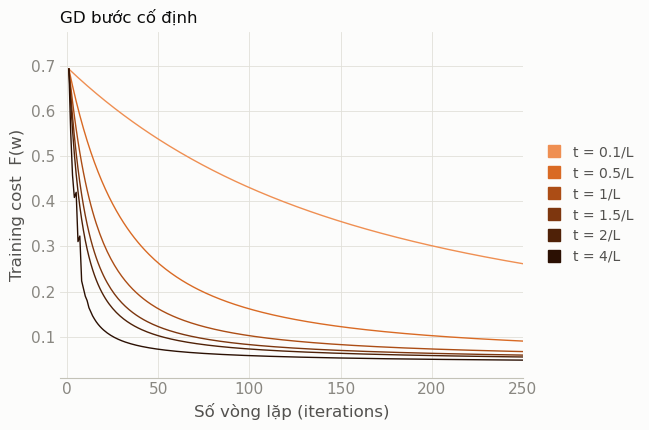

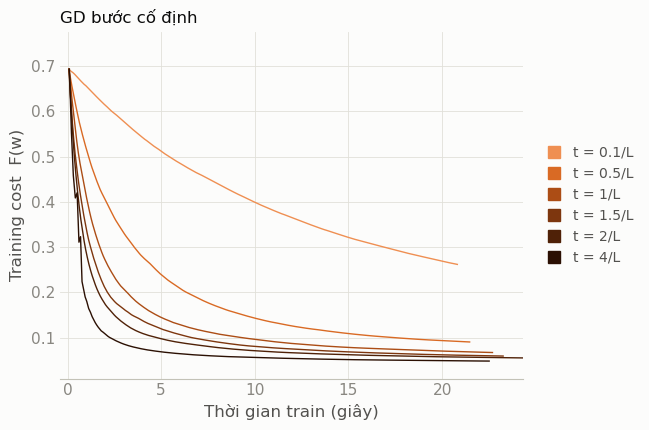

In [9]:
# ===== (1) GD buoc CO DINH: thu nhieu do dai buoc =====
BUOC = [0.1, 0.5, 1, 1.5, 2]        # boi cua 1/L (dung chung cho GD, Nesterov, Proximal)
BUOC_GD = BUOC + [4]               # rieng GD: thu them 4/L, vuot nguong 2/L cua ly thuyet
duong_cd = [("t = %g/L" % k,)
            + gradient_descent(X_tr, y_tr, LAM, k / L0, VONG)[1:] for k in BUOC_GD]

for ten, F, t in duong_cd:
    xong = "phân kỳ" if not np.isfinite(F[-1]) else "F = %.9f" % F[-1]
    print("%-10s  %-20s  %.4g giây" % (ten, xong, t[-1]))

ve(duong_cd, theo_thoi_gian=False, tieu_de="GD bước cố định",
   luu="gd_codinh_vonglap.pdf")
ve(duong_cd, theo_thoi_gian=True,  tieu_de="GD bước cố định",
   luu="gd_codinh_thoigian.pdf")

$\beta$ = 0.1   F = 0.043633682   50.88 giây
$\beta$ = 0.3   F = 0.043648080   51.73 giây
$\beta$ = 0.5   F = 0.043676758   56.98 giây
$\beta$ = 0.7   F = 0.043691714   89.81 giây
$\beta$ = 0.9   F = 0.043682590   149.8 giây


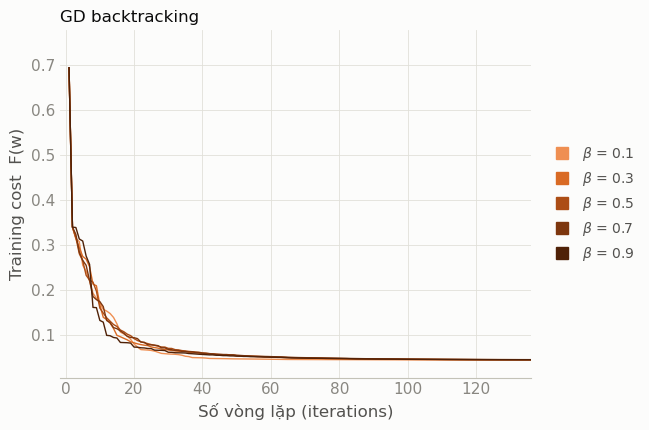

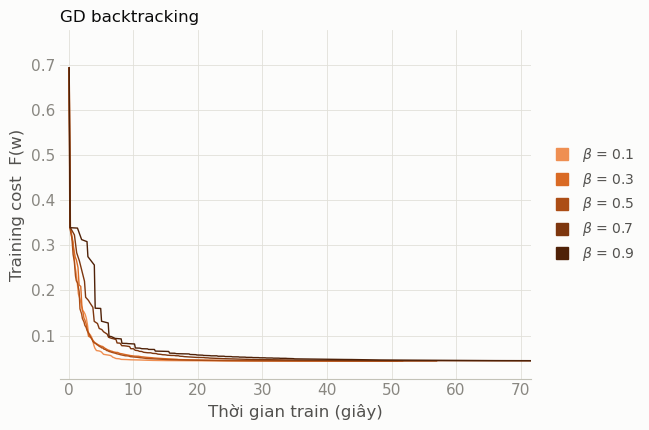

In [10]:
# ===== (2) GD BACKTRACKING: thu nhieu he so co buoc beta =====
# beta nho  -> co manh, it lan thu ben trong nhung buoc chon duoc tho
# beta lon  -> do ki, buoc sat nguong hon nhung moi vong phai tinh F nhieu lan
BETA = [0.1, 0.3, 0.5, 0.7, 0.9]
duong_bt = [("$\\beta$ = %g" % b,) + gradient_descent_bt(X_tr, y_tr, LAM, VONG, beta=b)[1:]
            for b in BETA]

for ten, F, t in duong_bt:
    print("%-14s  F = %.9f   %.4g giây" % (ten, F[-1], t[-1]))

ve(duong_bt, theo_thoi_gian=False, tieu_de="GD backtracking",
   luu="gd_bt_vonglap.pdf")
ve(duong_bt, theo_thoi_gian=True,  tieu_de="GD backtracking",
   luu="gd_bt_thoigian.pdf")

---
## 3b. GD tăng tốc (Nesterov)

GD thường chỉ đạt tốc độ $O(1/k)$ cho hàm lồi trơn. Nesterov chỉ ra cách đạt $O(1/k^2)$ mà
mỗi vòng vẫn rẻ như GD (một gradient) — mẹo là **không đi từ điểm đang đứng** mà đi từ một
**điểm ngoại suy** $v_k$, "nhìn trước" hướng mà $w$ vừa di chuyển:

$$w_{k+1}=v_k-t\nabla f(v_k),\qquad
v_{k+1}=w_{k+1}+\frac{\theta_k-1}{\theta_{k+1}}(w_{k+1}-w_k),\qquad
\theta_{k+1}=\frac{1+\sqrt{1+4\theta_k^2}}2,\quad\theta_0=1$$

$\theta_k\to\infty$ nên hệ số quán tính $(\theta_k-1)/\theta_{k+1}\to1$: càng về sau bước
ngoại suy càng dài, giống "đà" tích luỹ từ các bước trước.

Hai điều phải nhớ khi đọc hình:

- **Vẽ $F(w_k)$, không phải $F(v_k)$.** $w_k$ là điểm thật sự đang có; $v_k$ chỉ là nơi lấy
  gradient. $v_k$ có thể "vọt lố" nên $F(v_k)$ không đảm bảo giảm đơn điệu — dùng nó để vẽ
  sẽ ra đường gợn dù thuật toán vẫn đúng.
- **Vẫn dùng bước cố định $t=1/L$ như GD.** Nesterov không cần biết độ lồi mạnh của $f$,
  chỉ cần $L$, nên so với GD bước cố định là công bằng: cùng thông tin, khác cách dùng.

In [11]:
def gd_nesterov(X, y, lam, buoc, so_vong=1000):
    """GD tang toc (Nesterov) tren bai toan Ridge. v = diem ngoai suy, dao ham lay tai v;
    F ghi lai la F(w) (diem THUC dang co) vi F(v) khong dam bao giam don dieu."""
    w = np.zeros(X.shape[1])
    v = w.copy()
    theta = 1.0
    F_list, t_list = [], []
    t0 = time.time()
    for i in range(so_vong):
        F = ridge(w, X, y, lam)[0]
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):
            break
        g = ridge(v, X, y, lam)[1]
        w_moi = v - buoc * g
        theta_moi = (1 + np.sqrt(1 + 4 * theta ** 2)) / 2
        v = w_moi + (theta - 1) / theta_moi * (w_moi - w)
        w, theta = w_moi, theta_moi
    return w, F_list, t_list

t = 0.1/L   F = 0.046998445       46.28 giây
t = 0.5/L   F = 0.043779896       45.39 giây
t = 1/L     F = 0.043677457       48.44 giây
t = 1.5/L   F = 0.043671404       38.79 giây
t = 2/L     F = 0.043636427       49.67 giây


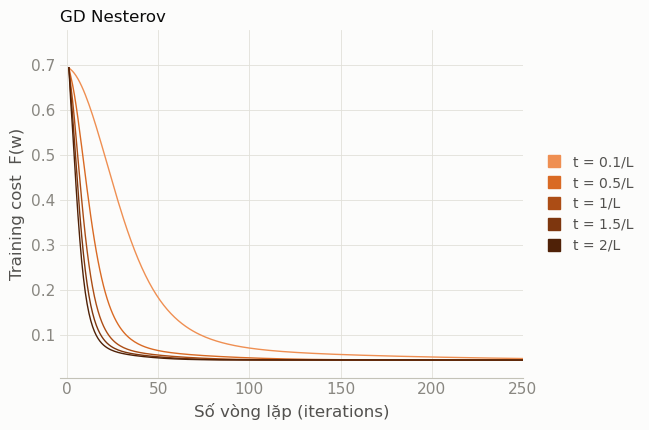

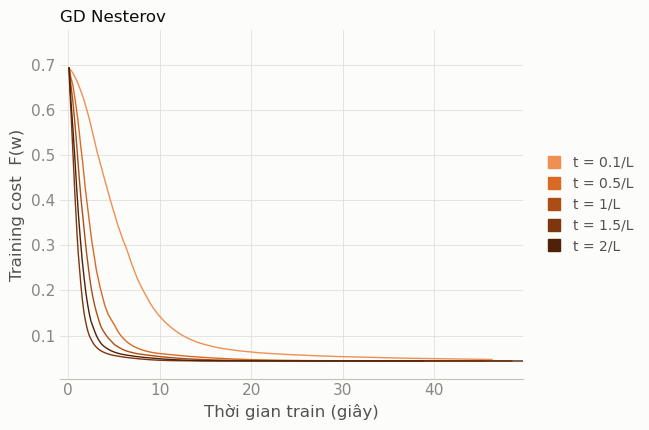


So với GD thường bước 1/L (cùng 250 vòng):  GD F = 0.067111610   Nesterov F = 0.043636427


In [12]:
# ===== GD Nesterov: thu nhieu do dai buoc (van la boi cua 1/L) =====
duong_acc = [("t = %g/L" % k,)
             + gd_nesterov(X_tr, y_tr, LAM, k / L0, VONG)[1:] for k in BUOC]

for ten, F, t in duong_acc:
    xong = "phân kỳ" if not np.isfinite(F[-1]) else "F = %.9f" % F[-1]
    print("%-10s  %-20s  %.4g giây" % (ten, xong, t[-1]))

ve(duong_acc, theo_thoi_gian=False, tieu_de="GD Nesterov",
   luu="nesterov_vonglap.pdf")
ve(duong_acc, theo_thoi_gian=True,  tieu_de="GD Nesterov",
   luu="nesterov_thoigian.pdf")

diem_acc = [F[-1] if np.isfinite(F[-1]) else np.inf for _, F, _ in duong_acc]
gd_1L = duong_cd[BUOC.index(1)]
print("\nSo với GD thường bước 1/L (cùng %d vòng):  GD F = %.9f   Nesterov F = %.9f"
      % (VONG, gd_1L[1][-1], min(diem_acc)))

---
## 3c. Newton

GD chỉ dùng đạo hàm bậc nhất nên phải đi theo $-\nabla F$ với một bước chung cho mọi hướng.
Newton dùng thêm **Hessian** để "nắn" hướng theo độ cong: hướng cong mạnh thì đi ngắn, hướng
thoải thì đi dài.

$$w_{k+1}=w_k-t_k\,d_k,\qquad \nabla^2F(w_k)\,d_k=\nabla F(w_k),\qquad
\nabla^2F(w)=\frac1nX^\top\mathrm{diag}\big(\sigma_i(1-\sigma_i)\big)X+\lambda I'$$

($I'$ là ma trận đơn vị bỏ phần tử của intercept, vì intercept không bị phạt.)

- **Bước cố định** $t_k=t$: $t=1$ là bước Newton thuần; $t<1$ gọi là *damped Newton*.
- **Backtracking**: mỗi vòng thử $t=1$ trước, chưa thoả Armijo
  $F(w-td)\le F(w)-c\,t\,\nabla F^\top d$ thì nhân $\beta$. Gần nghiệm $t=1$ luôn được nhận
  nên giữ được hội tụ **bậc hai**.

Mỗi vòng Newton đắt hơn GD nhiều (dựng Hessian $d\times d$ tốn $O(nd^2)$ và giải hệ $O(d^3)$),
nhưng ở đây $d\approx160$ vẫn nhỏ nên rẻ — và chỉ cần vài vòng. Vì vậy Newton chạy `VONG_NT` vòng
thay vì `VONG`.

In [13]:
def newton(X, y, lam, buoc=1.0, so_vong=30, backtracking=False, c=1e-4, beta=0.5):
    """Newton tren bai toan Ridge. buoc = do dai buoc co dinh (bo qua neu backtracking=True);
    backtracking=True -> moi vong thu buoc 1 truoc, chua du giam (Armijo) thi nhan beta."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    phat = np.full(X.shape[1], lam)
    phat[0] = 0.0                                       # intercept khong bi phat
    t0 = time.time()
    for k in range(so_vong):
        F, g = ridge(w, X, y, lam)
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):
            break
        s = sigmoid(X @ w)
        s = s * (1 - s)
        H = X.T @ (X * s[:, None]) / len(y) + np.diag(phat)
        huong = np.linalg.solve(H, g)
        t = buoc
        if backtracking:
            t = 1.0
            giam = g @ huong                            # = g^T H^-1 g > 0
            while t > 1e-12 and ridge(w - t * huong, X, y, lam)[0] > F - c * t * giam:
                t = t * beta
        w = w - t * huong
    return w, F_list, t_list

t = 0.1         F = 0.062376531       17.78 giây
t = 0.25        F = 0.043642542       18.08 giây
t = 0.5         F = 0.043630121       15.75 giây
t = 1           F = 0.043630121       16.02 giây
$\beta$ = 0.1   F = 0.043630121       23.3 giây
$\beta$ = 0.5   F = 0.043630121       30.16 giây
$\beta$ = 0.9   F = 0.043630121       176.8 giây


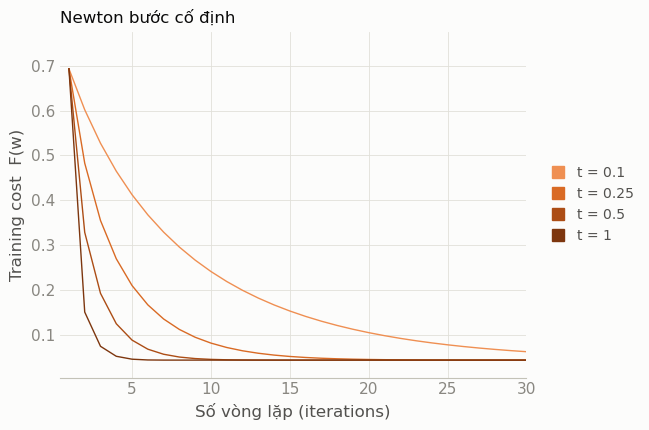

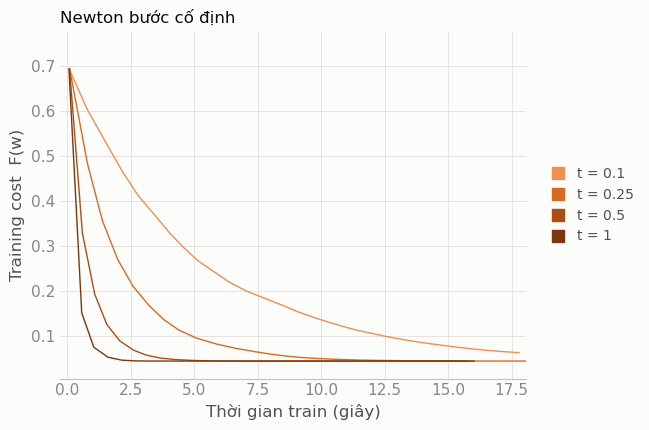

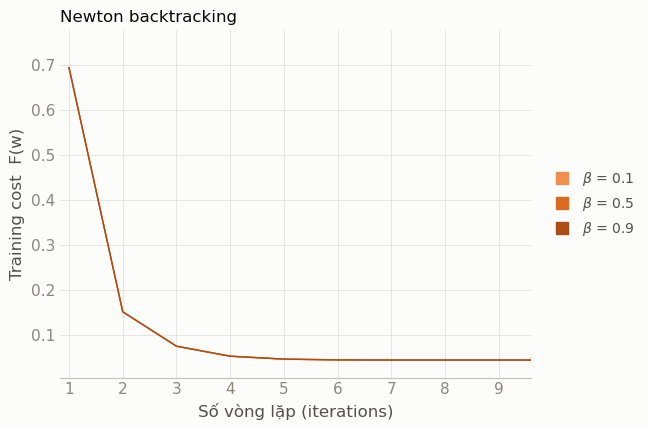

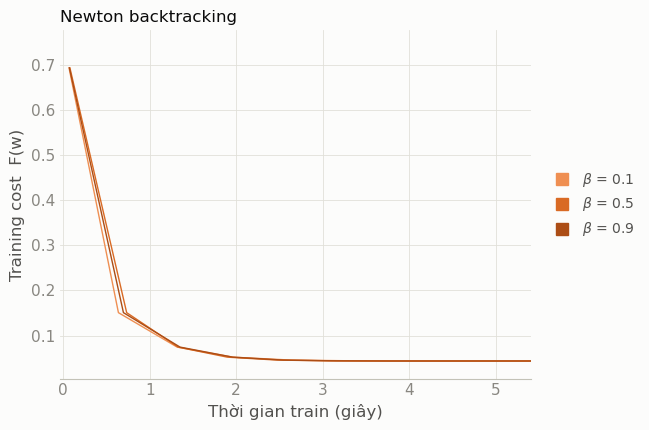

In [14]:
# ===== Newton: bước cố định (quét t) và backtracking (quét beta) =====
BUOC_NT = [0.1, 0.25, 0.5, 1.0]
duong_nt_cd = [("t = %g" % b,) + newton(X_tr, y_tr, LAM, buoc=b, so_vong=VONG_NT)[1:] for b in BUOC_NT]
BETA_NT = [0.1, 0.5, 0.9]
duong_nt_bt = [("$\\beta$ = %g" % b,) + newton(X_tr, y_tr, LAM, so_vong=VONG_NT, backtracking=True, beta=b)[1:]
               for b in BETA_NT]

for ten, F, t in duong_nt_cd + duong_nt_bt:
    xong = "phân kỳ" if not np.isfinite(F[-1]) else "F = %.9f" % F[-1]
    print("%-14s  %-20s  %.4g giây" % (ten, xong, t[-1]))

ve(duong_nt_cd, theo_thoi_gian=False, tieu_de="Newton bước cố định", luu="newton_codinh_vonglap.pdf")
ve(duong_nt_cd, theo_thoi_gian=True,  tieu_de="Newton bước cố định", luu="newton_codinh_thoigian.pdf")
ve(duong_nt_bt, theo_thoi_gian=False, tieu_de="Newton backtracking", luu="newton_bt_vonglap.pdf")
ve(duong_nt_bt, theo_thoi_gian=True,  tieu_de="Newton backtracking", luu="newton_bt_thoigian.pdf")

---
## 4. SGD

Khác GD duy nhất ở chỗ **dùng bao nhiêu điểm để tính gradient mỗi lần cập nhật**. Gradient
thật là trung bình trên cả $n$ điểm; SGD thay nó bằng trung bình trên một **mini-batch** $B$
điểm lấy ngẫu nhiên:

$$\nabla\ell(w)\;\approx\;\frac1B\sum_{i\in\mathcal{B}}\nabla\ell_i(w)$$

Ước lượng này **không chệch** nhưng có phương sai $\sigma^2/B$. Rẻ hơn $n/B$ lần nên đi được
nhiều bước hơn hẳn trong cùng thời gian, đổi lại đường đi zíc zắc và **không dừng hẳn**: với
bước cố định nó chỉ lảng vảng quanh nghiệm trong một "quả cầu nhiễu". Muốn hội tụ thật phải
cho bước teo dần theo điều kiện Robbins-Monro:

$$\sum_k\eta_k=\infty,\qquad\sum_k\eta_k^2<\infty\quad\Longrightarrow\quad
\eta_k=\frac{\eta_0}{1+k}\ \ \text{hoặc}\ \ \frac{\eta_0}{\sqrt{1+k}}$$

Hai quyết định về cách đo, không thì so sánh sai:

- **Không dùng $B=1$.** Ở đây $d\approx160$, một bước SGD là phép nhân trên vector vài trăm phần tử —
  overhead của numpy nuốt trọn thời gian tính, trong khi một bước GD là **một** lệnh BLAS
  trên ma trận lớn chạy hết công suất CPU. $B=1$ sẽ chậm hơn GD theo giây dù ít phép tính hơn.
- **Trục hoành đếm theo epoch.** Một epoch SGD = một lượt đọc hết dữ liệu = $n/B$ lần cập
  nhật, ngang chi phí một vòng GD. Nếu đếm theo lần cập nhật thì đường GD co lại thành một
  cái chấm. Đại lượng đem vẽ là **loss trên chính mini-batch** sắp dùng để cập nhật (ghi `DO_MOI`
  lần mỗi epoch), nên đường **gợn** đúng bản chất nhiễu của SGD. Đồng hồ **tạm dừng** lúc
  ghi — phép đo là để vẽ hình, không phải chi phí của thuật toán.

**Backtracking không dùng được cho SGD**: điều kiện Armijo cần so $F$ trước/sau, mà $F$ trên
mini-batch là số nhiễu nên nó sẽ chấp nhận hoặc từ chối bừa.

In [15]:
def sgd(X, y, lam, eta0, batch=4096, so_epoch=42, lich="1/k", seed=0, do_moi=10):
    """SGD mini-batch tren Ridge. Tra ve w + lich su loss, thoi gian.
       lich   = "co dinh" -> eta khong doi
              = "1/k"     -> eta0 / (1 + k)
              = "1/sqrt"  -> eta0 / sqrt(1 + k)          (k = so epoch da chay)
       do_moi = ghi loss bao nhieu lan trong moi epoch (chi de ve hinh).
    Diem dau la F(0) tren toan bo du lieu; cac diem sau la loss tren CHINH mini-batch sap
    dung de cap nhat -> do thi gon, dung ban chat nhieu cua SGD (F toan bo thi muot, xem muc duoi)."""
    rng = np.random.default_rng(seed)
    n_ = X.shape[0]
    so_batch = (n_ + batch - 1) // batch
    # DUNG "so_batch // do_moi": lam tron xuong se ra nhieu hon do_moi lan do moi epoch,
    # truc hoanh se dai hon so epoch that. Chot cung dung do_moi moc bang linspace.
    do_moi = min(do_moi, so_batch)
    moc = set(np.linspace(so_batch / do_moi, so_batch, do_moi).astype(int) - 1)
    w = np.zeros(X.shape[1])
    F_list, t_list = [ridge(w, X, y, lam)[0]], [0.0]
    tong = 0.0

    for k in range(so_epoch):
        eta = (eta0 if lich == "co dinh" else
               eta0 / (1 + k) if lich == "1/k" else eta0 / np.sqrt(1 + k))
        thu_tu = rng.permutation(n_)
        for j in range(so_batch):
            t0 = time.time()
            idx = thu_tu[j * batch:(j + 1) * batch]
            Xb, yb = X[idx], y[idx]
            tong += time.time() - t0
            if j in moc:                       # dong ho DUNG trong luc ghi loss
                F_list.append(ridge(w, Xb, yb, lam)[0])
                t_list.append(tong)
            t0 = time.time()
            g = Xb.T @ (sigmoid(Xb @ w) - yb) / len(idx)
            g[1:] += lam * w[1:]
            w = w - eta * g
            tong += time.time() - t0
        if not np.isfinite(F_list[-1]):
            break
    return w, F_list, t_list


def diem_cuoi(F, trung_binh=False):
    """Diem de chon setup tot nhat. Mac dinh = gia tri CUOI (GD, Newton... di xuong deu).
    trung_binh=True cho SGD: lay TRUNG BINH DO_MOI gia tri cuoi (~ epoch cuoi), vi mot gia tri
    loss mini-batch don le qua nhieu."""
    F = np.asarray(F)
    if not np.isfinite(F[-1]):
        return np.inf
    return np.mean(F[-DO_MOI:]) if trung_binh else F[-1]

$\alpha_0$ = 0.01   loss epoch cuối = 0.063311583     49.33 giây
$\alpha_0$ = 0.05   loss epoch cuối = 0.046309468     49.1 giây
$\alpha_0$ = 0.2    loss epoch cuối = 0.044234274     49.71 giây
$\alpha_0$ = 1      loss epoch cuối = 0.044296401     51.04 giây
$\alpha_0$ = 5      loss epoch cuối = 0.047352948     49.88 giây


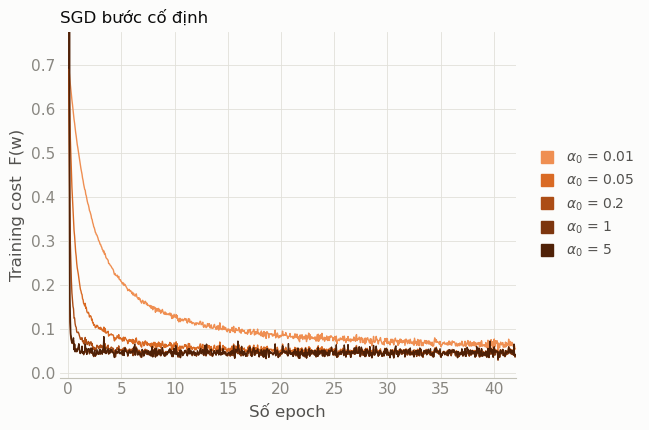

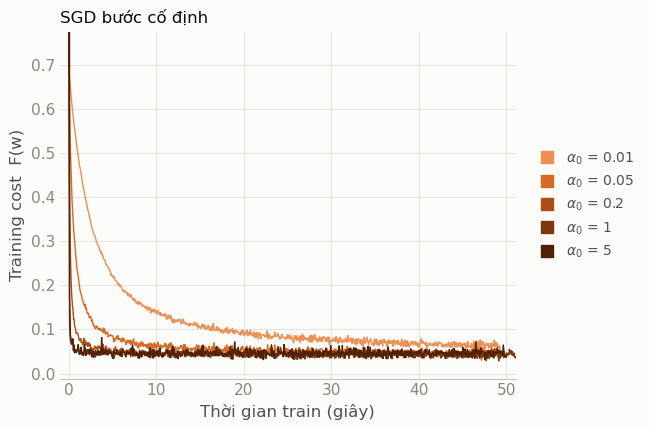

In [16]:
# ===== (1) SGD: quet do dai buoc dau eta0, buoc CO DINH =====
ETA = [0.01, 0.05, 0.2, 1.0, 5.0]
duong_sgd = [("$\\alpha_0$ = %g" % e,) + sgd(X_tr, y_tr, LAM, e, so_epoch=EPOCH, do_moi=DO_MOI, lich="co dinh")[1:]
             for e in ETA]

for ten, F, t in duong_sgd:
    xong = "phân kỳ" if not np.isfinite(F[-1]) else "loss epoch cuối = %.9f" % diem_cuoi(F, trung_binh=True)
    print("%-18s  %-32s  %.4g giây" % (ten, xong, t[-1]))

ve(duong_sgd, theo_thoi_gian=False, ten_x="Số epoch", chia_x=DO_MOI,
   tieu_de="SGD bước cố định", luu="sgd_eta_epoch.pdf")
ve(duong_sgd, theo_thoi_gian=True,
   tieu_de="SGD bước cố định", luu="sgd_eta_thoigian.pdf")

alpha0 (learning rate) tot nhat o buoc co dinh: 0.2


$\alpha_k=\alpha_0$             loss epoch cuối = 0.044234274   51.23 giây
$\alpha_k=\alpha_0/\sqrt{k}$    loss epoch cuối = 0.045913390   48.8 giây
$\alpha_k=\alpha_0/k$           loss epoch cuối = 0.052650018   49.98 giây


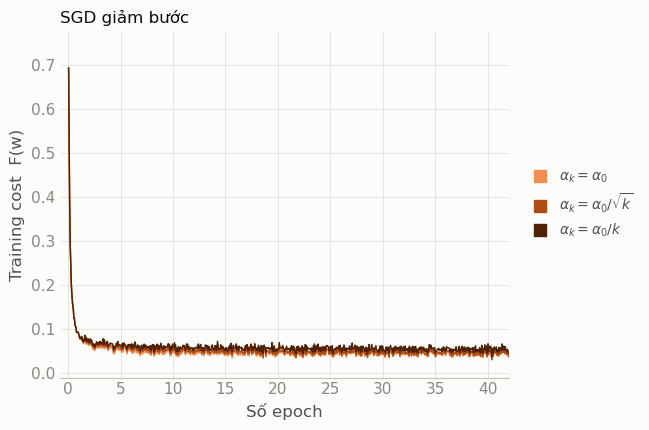

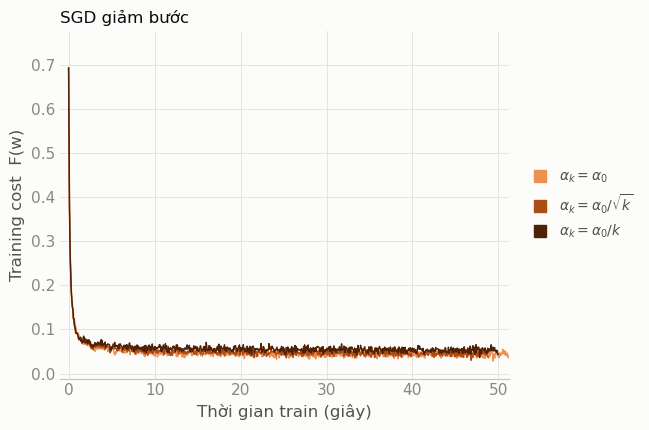

In [17]:
# ===== (2) SGD: giu eta0 tot nhat, doi LICH TEO BUOC =====
eta_tot = ETA[int(np.argmin([diem_cuoi(F, trung_binh=True) for _, F, _ in duong_sgd]))]
print("alpha0 (learning rate) tot nhat o buoc co dinh:", eta_tot)

TEN_LICH = {"co dinh": r"$\alpha_k=\alpha_0$",
            "1/sqrt":  r"$\alpha_k=\alpha_0/\sqrt{k}$",
            "1/k":     r"$\alpha_k=\alpha_0/k$"}
duong_lich = [(TEN_LICH[l],) + sgd(X_tr, y_tr, LAM, eta_tot, so_epoch=EPOCH, do_moi=DO_MOI, lich=l)[1:]
              for l in ["co dinh", "1/sqrt", "1/k"]]
for ten, F, t in duong_lich:
    print("%-30s  loss epoch cuối = %.9f   %.4g giây" % (ten, diem_cuoi(F, trung_binh=True), t[-1]))

mau_lich = [RAMP[0], RAMP[2], RAMP[4]]      # lich giam buoc co thu tu -> dung RAMP nhu cac o quet khac
ve(duong_lich, theo_thoi_gian=False, mau=mau_lich, ten_x="Số epoch", chia_x=DO_MOI,
   tieu_de="SGD giảm bước", luu="sgd_lich_epoch.pdf")
ve(duong_lich, theo_thoi_gian=True, mau=mau_lich,
   tieu_de="SGD giảm bước", luu="sgd_lich_thoigian.pdf")

---
### Loss mini-batch và $F$ trên toàn bộ dữ liệu

Các hình SGD ở trên vẽ **loss trên mini-batch** nên gợn. Nếu thay bằng $F$ đo trên **toàn bộ**
`X, y` tại $w_k$ (như bản trước) thì đường lại mượt như GD: bước cập nhật vẫn nhiễu (mỗi bước
chỉ nhìn batch/n ≈ 0,05% dữ liệu), nhưng $F$ toàn bộ là một con số **tất định**, không phụ
thuộc batch nào. Đường mượt vì trục tung mượt, không phải vì đường đi của $w_k$ mượt.

Kiểm chứng: vẽ cả hai đại lượng cạnh nhau trên cùng một lần chạy.

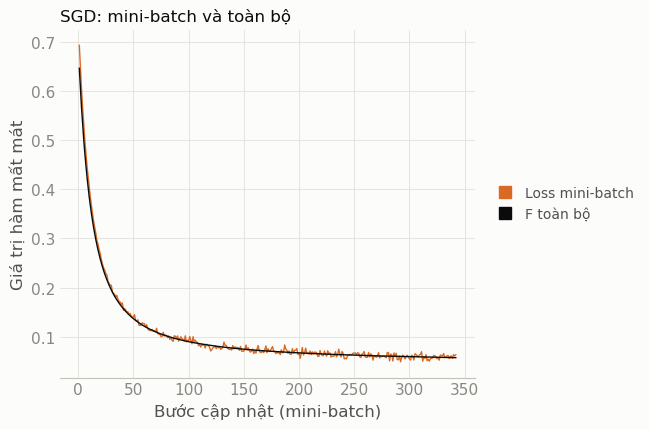

Độ lệch chuẩn của loss trên mini-batch: 0.09295   |   của F trên toàn bộ: 0.08728


In [18]:
# ===== F tren TOAN BO du lieu vs loss tren TUNG mini-batch =====
def sgd_vet_ca_hai(X, y, lam, eta0, batch=4096, so_epoch=3, seed=0):
    """Giong sgd() nhung ghi CA HAI: F tren toan bo va loss tren dung
    mini-batch vua dung de cap nhat (chi de xem, khong dung de dieu khien buoc)."""
    rng = np.random.default_rng(seed)
    n_ = X.shape[0]
    so_batch = (n_ + batch - 1) // batch
    w = np.zeros(X.shape[1])
    F_toanbo, F_batch = [], []
    for k in range(so_epoch):
        thu_tu = rng.permutation(n_)
        for j in range(so_batch):
            idx = thu_tu[j * batch:(j + 1) * batch]
            Xb, yb = X[idx], y[idx]
            F_batch.append(ridge(w, Xb, yb, lam)[0])      # loss TRUOC khi cap nhat, tren batch
            g = Xb.T @ (sigmoid(Xb @ w) - yb) / len(idx)
            g[1:] += lam * w[1:]
            w = w - eta0 * g
            F_toanbo.append(ridge(w, X, y, lam)[0])       # F tren TOAN BO, moi buoc (chi de minh hoa)
    return F_toanbo, F_batch


F_toanbo, F_batch = sgd_vet_ca_hai(X_tr, y_tr, LAM, eta_tot, so_epoch=3)
buoc_x = np.arange(1, len(F_toanbo) + 1)

fig, ax = plt.subplots(figsize=(6.6, 4.4), facecolor=NEN)
ax.set_facecolor(NEN)
ax.plot(buoc_x, F_batch, color=RAMP[1], lw=NET)
ax.plot(buoc_x, F_toanbo, color=MUC, lw=NET)
trang_tri(ax, "Bước cập nhật (mini-batch)", "Giá trị hàm mất mát", "SGD: mini-batch và toàn bộ")
chu_giai(ax, [("Loss mini-batch", RAMP[1]), ("F toàn bộ", MUC)])
fig.tight_layout()
fig.savefig(HINH + "sgd_muot_vs_batch.pdf", bbox_inches="tight")
plt.show()

print("Độ lệch chuẩn của loss trên mini-batch: %.5f   |   của F trên toàn bộ: %.5f"
      % (np.std(F_batch), np.std(F_toanbo)))

---
## 5. Subgradient cho Lasso

Lasso thêm $\lambda_1\|w\|_1$, mà $|w_j|$ **không khả vi tại 0** nên không có gradient. Thay
vào đó dùng một phần tử bất kỳ của **dưới vi phân**:

$$\partial|w_j|=\begin{cases}\{\operatorname{sign}(w_j)\} & w_j\neq0\\[2pt]
[-1,\,1] & w_j=0\end{cases}$$

Ở toạ độ đang bằng 0 ta được cả một đoạn để chọn. Chọn **phần tử có chuẩn nhỏ nhất**, tức
đẩy $\nabla_j\ell$ ra ngoài đoạn $[-\lambda_1,\lambda_1]$:

$$s_j=\nabla_j\ell-\operatorname{clip}\big(\nabla_j\ell,\,-\lambda_1,\,\lambda_1\big)$$

Chọn thế có hai cái lợi. Thứ nhất, khi $|\nabla_j\ell|\le\lambda_1$ thì $s_j=0$ — toạ độ đó
**đứng yên tại 0**, nên phương pháp thật sự sinh ra nghiệm thưa. Thứ hai, $\|s\|$ chính là
thước đo tối ưu KKT: $s=0$ khi và chỉ khi $w$ là nghiệm.

Hai điều phải nhớ khi đọc hình:

- **Đây không phải phương pháp giảm.** $F$ có thể tăng ở một số vòng, hoàn toàn bình thường —
  đường sẽ gợn chứ không mượt như GD.
- **Bước bắt buộc teo dần.** Với bước cố định, $\|s\|$ không tiến về 0 ở lân cận nghiệm nên
  $F$ dao động mãi. Tốc độ chỉ đạt $O(1/\sqrt{k})$, chậm hơn hẳn GD — đó là cái giá của việc
  mất tính khả vi.

In [19]:
def subgradient(X, y, lam1, eta0, so_vong=250, lich="1/sqrt"):
    """Subgradient cho Lasso, chon phan tu CHUAN NHO NHAT cua duoi vi phan.
    Intercept (cot 0) khong bi phat nen giu nguyen gradient."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    t0 = time.time()
    for k in range(so_vong):
        F, g = lasso(w, X, y, lam1)          # g = gradient cua RIENG phan log-loss
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):
            break
        khac0 = np.zeros(len(w), bool)
        bang0 = np.zeros(len(w), bool)
        khac0[1:] = w[1:] != 0
        bang0[1:] = w[1:] == 0
        s = g.copy()
        s[khac0] += lam1 * np.sign(w[khac0])                     # w_j != 0: dao ham thuong
        s[bang0] = g[bang0] - np.clip(g[bang0], -lam1, lam1)     # w_j == 0: phan tu chuan nho nhat
        eta = eta0 / (1 + k) if lich == "1/k" else eta0 / np.sqrt(1 + k)
        w = w - eta * s
    return w, F_list, t_list

eta0 = 0.5    F = 0.106418727       he so khac 0: 118/160   20.57 giây


eta0 = 2      F = 0.061166248       he so khac 0: 154/160   20.85 giây


eta0 = 8      F = 0.051691918       he so khac 0: 154/160   21.42 giây


eta0 = 30     F = 0.055653268       he so khac 0: 122/160   20.92 giây


eta0 = 100    F = 0.105122912       he so khac 0: 124/160   21.33 giây


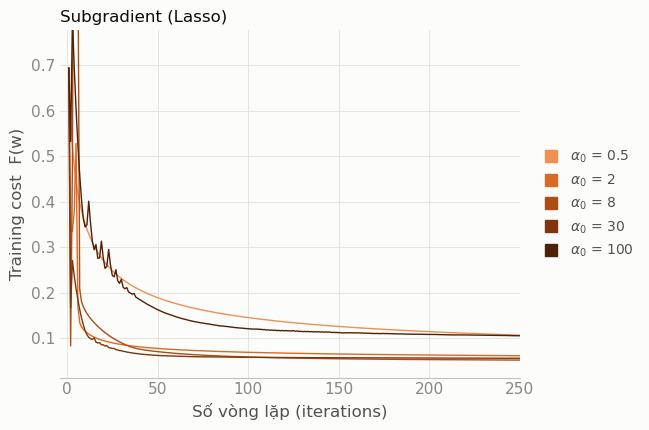

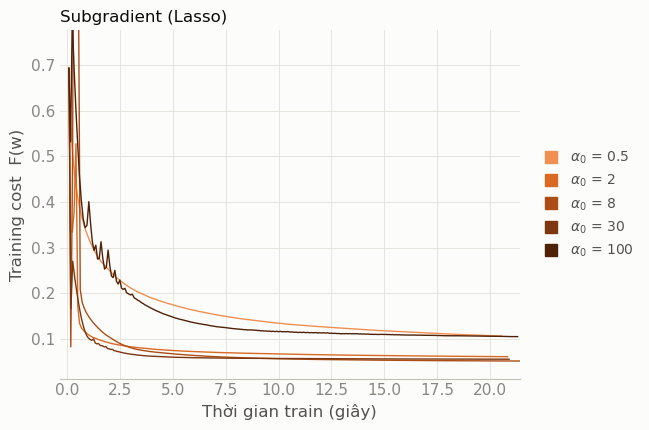

In [20]:
# ===== Subgradient: quet eta0 =====
ETA_SG = [0.5, 2.0, 8.0, 30.0, 100.0]
duong_sg, W_SG = [], []
for e in ETA_SG:
    w_sg, F, t = subgradient(X_tr, y_tr, LAM1, e, so_vong=VONG)
    duong_sg.append((r"$\alpha_0$ = %g" % e, F, t))
    W_SG.append(w_sg)
    xong = "phân kỳ" if not np.isfinite(F[-1]) else "F = %.9f" % F[-1]
    print("%-12s  %-20s  he so khac 0: %2d/%d   %.4g giây"
          % ("eta0 = %g" % e, xong, np.sum(w_sg[1:] != 0), len(w_sg) - 1, t[-1]))

ve(duong_sg, theo_thoi_gian=False, tieu_de="Subgradient (Lasso)",
   luu="subgrad_vonglap.pdf")
ve(duong_sg, theo_thoi_gian=True,  tieu_de="Subgradient (Lasso)",
   luu="subgrad_thoigian.pdf")

---
## 5b. Proximal gradient (ISTA) cho Lasso

Subgradient ở trên phải dùng bước **teo dần** ($O(1/\sqrt k)$) vì thông tin "không khả vi
tại 0" bị trộn thẳng vào một bước gradient chung. Cách khác: **tách riêng** phần trơn và
phần không trơn — đi một bước gradient trên $\ell$ (phần trơn) rồi "chốt" kết quả bằng
**prox** của $\lambda_1\|\cdot\|_1$:

$$w_{k+1}=\operatorname{prox}_{t\lambda_1\|\cdot\|_1}\big(w_k-t\nabla\ell(w_k)\big),
\qquad
\operatorname{prox}_{t\lambda_1\|\cdot\|_1}(v)_j=\operatorname{sign}(v_j)\max(|v_j|-t\lambda_1,\,0)$$

Đây gọi là **ISTA** (Iterative Shrinkage-Thresholding). Hai điểm khác subgradient:

- **Bước cố định $t=1/L$ dùng được luôn** — $L$ ở đây là hằng số Lipschitz của riêng $\ell$
  (không cộng $\lambda_2$ vì Lasso không có phần $L_2$), đúng bằng `L0` đã tính ở mục 3.
  Tốc độ hội tụ $O(1/k)$, nhanh hơn hẳn $O(1/\sqrt k)$ của subgradient.
- **Đặt hẳn hệ số về 0** trong một bước duy nhất (soft-threshold co thẳng những $|v_j|\le
  t\lambda_1$ về 0), trong khi subgradient chỉ *ngừng di chuyển* toạ độ đó khi may mắn rơi
  trúng 0.

In [21]:
def prox_l1(v, t, lam1):
    """prox cua g = lam1*||.||_1: soft-threshold. Cot 0 (intercept) khong bi phat -> giu nguyen."""
    out = np.sign(v) * np.maximum(np.abs(v) - t * lam1, 0)
    out[0] = v[0]
    return out


def proximal_gradient(X, y, lam1, buoc, so_vong=250):
    """ISTA cho Lasso: buoc gradient tren phan tron (log-loss) roi prox cho lam1*||w||_1."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    t0 = time.time()
    for i in range(so_vong):
        F, g = lasso(w, X, y, lam1)
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):
            break
        w = prox_l1(w - buoc * g, buoc, lam1)
    return w, F_list, t_list

k = 0.1         F = 0.262138352       hệ số khác 0: 44/160   20.67 giây


k = 0.5         F = 0.091618997       hệ số khác 0: 35/160   21.61 giây


k = 1           F = 0.069192316       hệ số khác 0: 35/160   22.26 giây


k = 1.5         F = 0.062007828       hệ số khác 0: 35/160   23.67 giây


k = 2           F = 0.058274120       hệ số khác 0: 30/160   22.79 giây


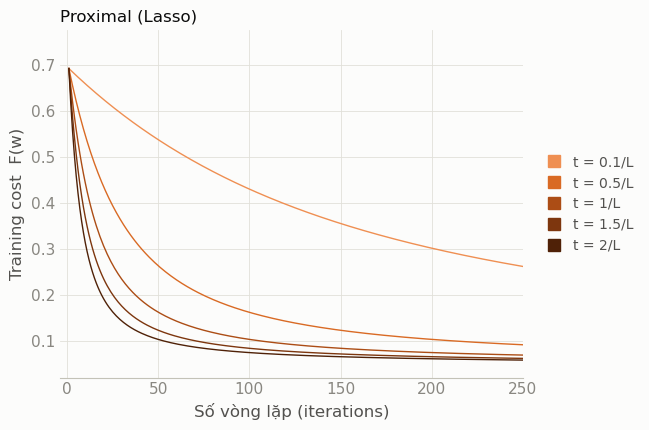

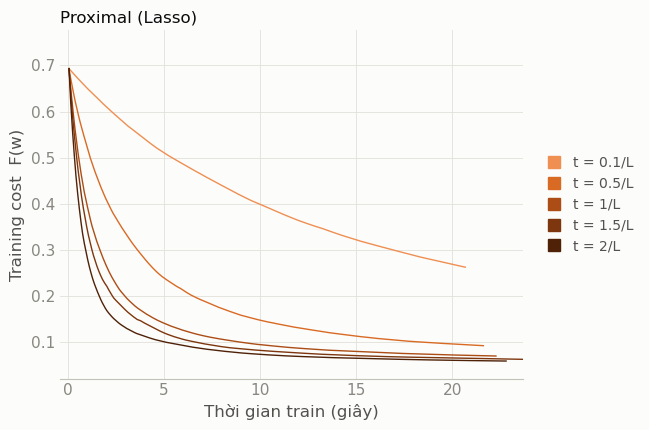

In [22]:
# ===== Proximal (ISTA): thu nhieu do dai buoc, van la boi cua 1/L =====
duong_prox, W_PX = [], []
for k in BUOC:
    w_px, F, t = proximal_gradient(X_tr, y_tr, LAM1, k / L0, VONG)
    ten = "t = %g/L" % k
    duong_prox.append((ten, F, t))
    W_PX.append(w_px)
    xong = "phân kỳ" if not np.isfinite(F[-1]) else "F = %.9f" % F[-1]
    print("%-14s  %-20s  hệ số khác 0: %2d/%d   %.4g giây"
          % ("k = %g" % k, xong, np.sum(w_px[1:] != 0), d - 1, t[-1]))

ve(duong_prox, theo_thoi_gian=False, tieu_de="Proximal (Lasso)",
   luu="proximal_vonglap.pdf")
ve(duong_prox, theo_thoi_gian=True,  tieu_de="Proximal (Lasso)",
   luu="proximal_thoigian.pdf")

---
## 6. Tổng kết: bốn setup tốt nhất so với thư viện

Mỗi thuật toán lấy **setup tốt nhất** đã xác định ở trên, rồi so với nhau và với sklearn ở
chế độ mặc định. So **giá trị hàm mục tiêu** và **thời gian tính**, đúng yêu cầu đề bài.

Điều kiện để so được: cả bốn đường phải tối thiểu hoá **cùng một hàm** $F$. GD bước cố định,
GD backtracking, GD Nesterov, Newton và SGD đều giải bài toán Ridge với cùng $\lambda$ nên nằm chung
một hình.

**Subgradient và Proximal thì không**, vì cả hai giải Lasso — hàm mục tiêu khác hẳn
($\lambda_1\|w\|_1$ thay cho $\tfrac{\lambda}{2}\|w\|_2^2$). Đặt chung một trục là so sai.
Chúng có bảng so riêng với nhau và với `LogisticRegression(penalty="l1")` ở dưới.

Quy đổi tham số để sklearn tối thiểu hoá đúng $F$ của mình: sklearn dùng
$\tfrac12\|w\|^2 + C\sum_i\ell_i$ (tổng), mình dùng $\tfrac1n\sum_i\ell_i+\tfrac{\lambda}{2}\|w\|^2$
(trung bình), nên $C=\dfrac{1}{n\lambda}$.

Thuật toán         setup tốt nhất                       F cuối         giây
----------------------------------------------------------------------------
GD bước cố định    t = 4/L                         0.048206446        22.51
GD backtracking    $\beta$ = 0.1                   0.043633682        50.88
GD Nesterov        t = 2/L                         0.043636427        49.67
Newton             $\beta$ = 0.1                   0.043630121         23.3
SGD                $\alpha_0$ = 0.2                0.044234274        49.71
sklearn            mặc định (lbfgs)                0.043639234        2.685
(SGD: F cuối là trung bình loss mini-batch ở epoch cuối, không phải F trên toàn bộ.)


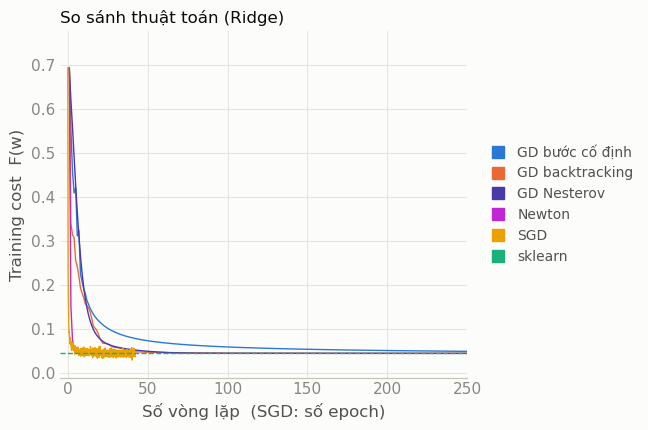

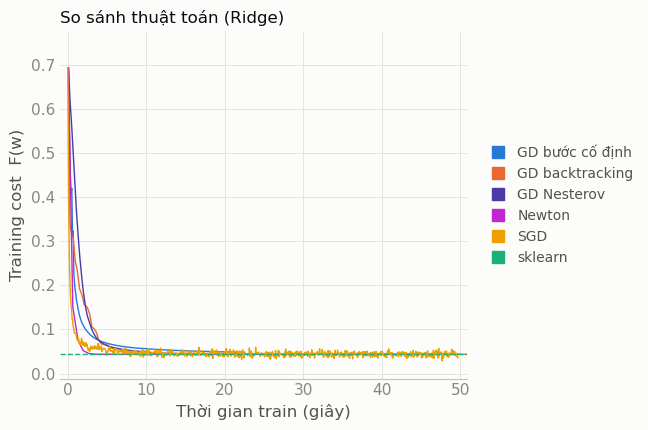

In [23]:
# ===== Ridge: 5 setup tot nhat + sklearn =====
def tot_nhat(ds, trung_binh=False):
    return ds[int(np.argmin([diem_cuoi(F, trung_binh) for _, F, _ in ds]))]

# doi nhan thanh TEN THUAT TOAN de legend giong het cac hinh so sanh khac
TT_RIDGE = ["GD bước cố định", "GD backtracking", "GD Nesterov", "Newton", "SGD"]
chon = [tot_nhat(duong_cd), tot_nhat(duong_bt), tot_nhat(duong_acc),
        tot_nhat(duong_nt_cd + duong_nt_bt), tot_nhat(duong_sgd, trung_binh=True)]
duong_top = [(tt,) + ds[1:] for tt, ds in zip(TT_RIDGE, chon)]

print("%-18s %-26s %16s %12s" % ("Thuật toán", "setup tốt nhất", "F cuối", "giây"))
print("-" * 76)
for tt, (setup, F, t) in zip(TT_RIDGE, chon):
    print("%-18s %-26s %16.9f %12.4g" % (tt, setup, diem_cuoi(F, tt == "SGD"), t[-1]))
print("%-18s %-26s %16.9f %12.4g" % ("sklearn", "mặc định (lbfgs)", F_sk, gio_sk))
print("(SGD: F cuối là trung bình loss mini-batch ở epoch cuối, không phải F trên toàn bộ.)")

# 1 vong GD/Newton = 1 luot doc het du lieu = 1 epoch SGD, nen SGD doi so lan ghi loss ra epoch
mau_top = [MAU_TT[tt] for tt in TT_RIDGE]
ve(duong_top, theo_thoi_gian=False, mau=mau_top, moc=(F_sk, gio_sk),
   chia_x=[DO_MOI if tt == "SGD" else 1 for tt in TT_RIDGE],
   ten_x="Số vòng lặp  (SGD: số epoch)",
   tieu_de="So sánh thuật toán (Ridge)", luu="tongket_vonglap.pdf")
ve(duong_top, theo_thoi_gian=True,  mau=mau_top, moc=(F_sk, gio_sk),
   tieu_de="So sánh thuật toán (Ridge)", luu="tongket_thoigian.pdf")

                                                              F Lasso         giây   hệ số khác 0
--------------------------------------------------------------------------------------------------
Subgradient, $\alpha_0$ = 8                               0.051691918        21.42        154/160
Proximal, t = 2/L                                         0.058274120        22.79         30/160
sklearn liblinear (penalty='l1')                          0.046688814        25.58         19/160


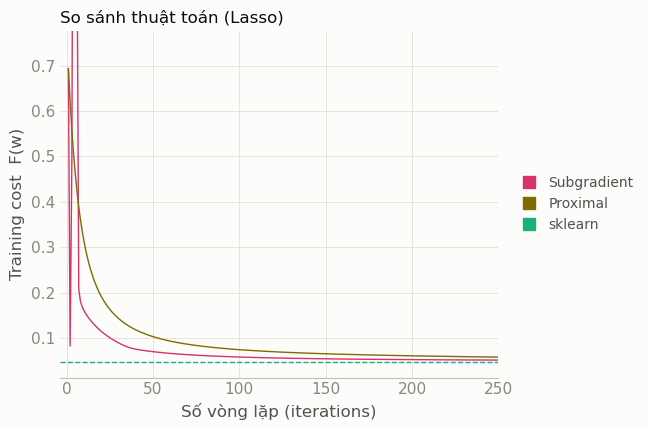

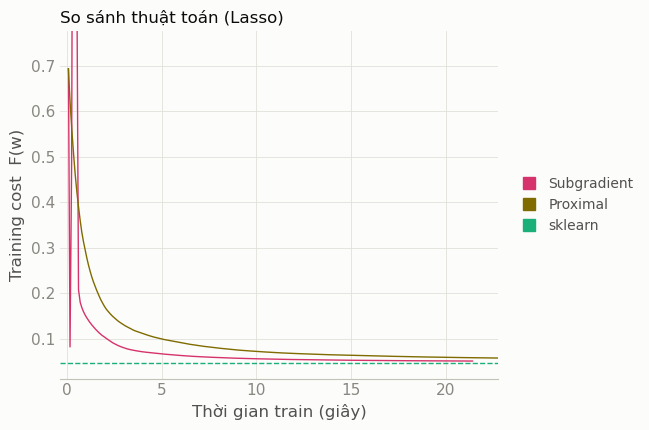

In [24]:
# ===== Lasso: subgradient vs proximal vs sklearn L1 (ham muc tieu KHAC, nen de rieng) =====
t0 = time.time()
sk1 = LogisticRegression(penalty="l1", C=1 / (n * LAM1), solver="liblinear").fit(X_tr[:, 1:], y_tr)
gio_sk1 = time.time() - t0
w_sk1 = np.r_[sk1.intercept_, sk1.coef_[0]]
F_sk1 = lasso(w_sk1, X_tr, y_tr, LAM1)[0]

i_sg = int(np.argmin([diem_cuoi(F) for _, F, _ in duong_sg]))
i_px = int(np.argmin([diem_cuoi(F) for _, F, _ in duong_prox]))
nhan_sg, F_sg_tot, t_sg_tot = duong_sg[i_sg]
nhan_px, F_px_tot, t_px_tot = duong_prox[i_px]
w_sg_tot, w_px_tot = W_SG[i_sg], W_PX[i_px]      # w cua DUNG setup tot nhat

print("%-52s %16s %12s %14s" % ("", "F Lasso", "giây", "hệ số khác 0"))
print("-" * 98)
for ten, F, t, w_cuoi in [("Subgradient, " + nhan_sg, F_sg_tot, t_sg_tot, w_sg_tot),
                          ("Proximal, " + nhan_px, F_px_tot, t_px_tot, w_px_tot)]:
    print("%-52s %16.9f %12.4g %10d/%d" % (ten, F[-1], t[-1], np.sum(w_cuoi[1:] != 0), len(w_cuoi) - 1))
print("%-52s %16.9f %12.4g %10d/%d"
      % ("sklearn liblinear (penalty='l1')", F_sk1, gio_sk1,
         np.sum(w_sk1[1:] != 0), len(w_sk1) - 1))

duong_lasso = [("Subgradient", F_sg_tot, t_sg_tot), ("Proximal", F_px_tot, t_px_tot)]
mau_lasso = [MAU_TT["Subgradient"], MAU_TT["Proximal"]]
ve(duong_lasso, theo_thoi_gian=False, mau=mau_lasso, moc=(F_sk1, gio_sk1),
   tieu_de="So sánh thuật toán (Lasso)", luu="lasso_vonglap.pdf")
ve(duong_lasso, theo_thoi_gian=True, mau=mau_lasso, moc=(F_sk1, gio_sk1),
   tieu_de="So sánh thuật toán (Lasso)", luu="lasso_thoigian.pdf")

---
## 6b. Best của từng thuật toán: số vòng hội tụ, thời gian hội tụ, hàm loss

Mỗi thuật toán lấy **setup tốt nhất**, so trên cùng một hình. Ridge và Lasso là hai hàm mục tiêu
khác nhau nên mỗi thuật toán được đo so với $F^{\star}$ của **chính bài toán nó giải**:

$$F^{\star} = \min\big(\text{F cuối của mọi thuật toán cùng bài toán},\ F_{\text{sklearn}}\big),
\qquad
k_\varepsilon = \min\Big\{k:\ \frac{F(w_k)-F^{\star}}{F^{\star}}\le\varepsilon\Big\},\quad \varepsilon=1\%$$

- **Số vòng hội tụ** $k_\varepsilon$ và **thời gian hội tụ** $t(k_\varepsilon)$; chưa đạt trong ngân
  sách thì ghi *chưa hội tụ*. SGD đếm theo **epoch** và dùng trung bình loss mini-batch mỗi epoch.
- **Hàm loss** so được giữa mọi thuật toán: log-loss **không cộng phạt**
  $\ell(w)=\frac1n\sum_i[\log(1+e^{z_i})-y_iz_i]$ trên train và validation.

F* Ridge = 0.043630121   F* Lasso = 0.046688814   (eps = 0.01)
Thuật toán        Bài    setup                        vòng       giây    logloss tr    logloss va
--------------------------------------------------------------------------------------------------
GD bước cố định   Ridge  t = 4/L                     > 250     > 22.5      0.047263      0.042971
GD backtracking   Ridge  $\beta$ = 0.1                  94      19.34      0.040656      0.036242
GD Nesterov       Ridge  t = 2/L                        82      16.42      0.040551      0.036113
Newton            Ridge  $\beta$ = 0.1                   5       3.38      0.040585      0.036167
SGD               Ridge  $\alpha_0$ = 0.2               20      23.81      0.040939      0.036546
sklearn           Ridge  lbfgs mặc định                 27       2.69      0.040654      0.036241
Subgradient       Lasso  $\alpha_0$ = 8              > 250     > 21.4      0.044118      0.039214
Proximal          Lasso  t = 2/L                     >

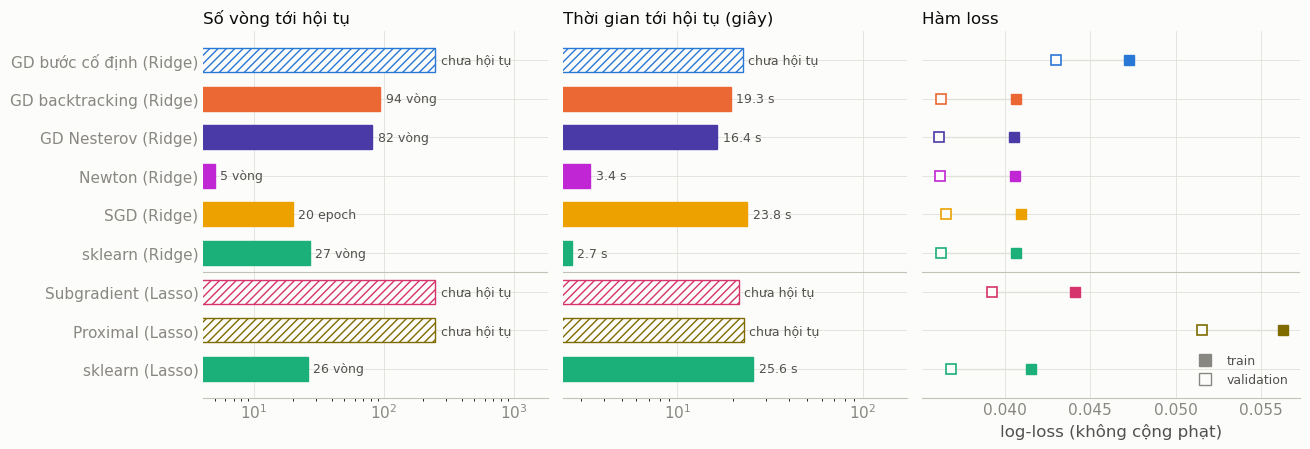

In [25]:
# ===== Best cua TUNG thuat toan =====
def chon(ds, trung_binh=False):
    return int(np.argmin([diem_cuoi(F, trung_binh) for _, F, _ in ds]))


def log_loss(w, X, y):
    z = X @ w
    return np.mean(np.logaddexp(0, z) - y * z)


EPS = 0.01
# cac o quet chi giu (nhan, F, t) -> chay lai DUNG setup tot nhat de lay w
i_nt = chon(duong_nt_cd + duong_nt_bt)
w_nt = (newton(X_tr, y_tr, LAM, buoc=BUOC_NT[i_nt], so_vong=VONG_NT) if i_nt < len(BUOC_NT) else
        newton(X_tr, y_tr, LAM, so_vong=VONG_NT, backtracking=True,
               beta=BETA_NT[i_nt - len(BUOC_NT)]))[0]
i_sgd = chon(duong_sgd, True)
best = [   # (thuat toan, bai toan, (nhan, F, t), w)
    ("GD bước cố định", "Ridge", duong_cd[chon(duong_cd)],
     gradient_descent(X_tr, y_tr, LAM, BUOC_GD[chon(duong_cd)] / L0, VONG)[0]),
    ("GD backtracking", "Ridge", duong_bt[chon(duong_bt)],
     gradient_descent_bt(X_tr, y_tr, LAM, VONG, beta=BETA[chon(duong_bt)])[0]),
    ("GD Nesterov", "Ridge", duong_acc[chon(duong_acc)],
     gd_nesterov(X_tr, y_tr, LAM, BUOC[chon(duong_acc)] / L0, VONG)[0]),
    ("Newton", "Ridge", (duong_nt_cd + duong_nt_bt)[i_nt], w_nt),
    ("SGD", "Ridge", duong_sgd[i_sgd],
     sgd(X_tr, y_tr, LAM, ETA[i_sgd], so_epoch=EPOCH, do_moi=DO_MOI, lich="co dinh")[0]),
    ("Subgradient", "Lasso", duong_sg[i_sg], w_sg_tot),
    ("Proximal", "Lasso", duong_prox[i_px], w_px_tot),
]
F_sao = {"Ridge": min([F_sk] + [diem_cuoi(F, tt == "SGD") for tt, bt, (_, F, _), _ in best if bt == "Ridge"]),
         "Lasso": min([F_sk1] + [diem_cuoi(F) for tt, bt, (_, F, _), _ in best if bt == "Lasso"])}

ds_best = []   # (ten, bai toan, setup, so vong, giay, hoi tu?, ngan sach, log-loss train, log-loss val)
for tt, bt, (setup, F, t), w in best:
    F, t = np.asarray(F), np.asarray(t)
    if tt == "SGD":                                   # trung binh loss mini-batch tung epoch
        F = F[1:].reshape(-1, DO_MOI).mean(1)
        t = t[DO_MOI::DO_MOI]
        dat = np.nonzero((F - F_sao[bt]) / F_sao[bt] <= EPS)[0]
        k = dat[0] + 1 if len(dat) else None
        giay = t[dat[0]] if len(dat) else None
    else:
        dat = np.nonzero((F - F_sao[bt]) / F_sao[bt] <= EPS)[0]
        k = dat[0] if len(dat) else None
        giay = t[dat[0]] if len(dat) else None
    ngan_sach = (EPOCH if tt == "SGD" else VONG_NT if tt == "Newton" else VONG, t[-1])
    ds_best.append((tt, bt, setup, k, giay, k is not None, ngan_sach,
                 log_loss(w, X_tr, y_tr), log_loss(w, X_va, y_va)))

w_sk = np.r_[sk.intercept_, sk.coef_[0]]
ds_best.insert(5, ("sklearn", "Ridge", "lbfgs mặc định", int(sk.n_iter_[0]), gio_sk, True, None,
             log_loss(w_sk, X_tr, y_tr), log_loss(w_sk, X_va, y_va)))
ds_best.append(("sklearn", "Lasso", "liblinear, L1", int(np.max(sk1.n_iter_)), gio_sk1, True, None,
             log_loss(w_sk1, X_tr, y_tr), log_loss(w_sk1, X_va, y_va)))

print("F* Ridge = %.9f   F* Lasso = %.9f   (eps = %g)" % (F_sao["Ridge"], F_sao["Lasso"], EPS))
print("%-17s %-6s %-22s %10s %10s %13s %13s" % ("Thuật toán", "Bài", "setup", "vòng", "giây",
                                               "logloss tr", "logloss va"))
print("-" * 98)
for tt, bt, setup, k, giay, ht, ns, l_tr, l_va in ds_best:
    vong = str(k) if ht else "> %d" % ns[0]
    s = "%.2f" % giay if ht else "> %.1f" % ns[1]
    print("%-17s %-6s %-22s %10s %10s %13.6f %13.6f" % (tt, bt, setup, vong, s, l_tr, l_va))

# --------------------------------------------------- hinh: 3 khung chung truc tung
ten_hang = ["%s (%s)" % (tt, bt) for tt, bt, *_ in ds_best]
mau_hang = [MAU_TT[tt] for tt, *_ in ds_best]
y = np.arange(len(ds_best))[::-1]
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.6), facecolor=NEN, sharey=True,
                         gridspec_kw={"width_ratios": [1, 1, 1.1]})
for ax, cot, tieu_de, don_vi in [(axes[0], 3, "Số vòng tới hội tụ", "vòng"),
                                (axes[1], 4, "Thời gian tới hội tụ (giây)", "s")]:
    ax.set_facecolor(NEN)
    for yi, h, c in zip(y, ds_best, mau_hang):
        ht = h[5]
        gt = h[cot] if ht else (h[6][0] if cot == 3 else h[6][1])
        ax.barh(yi, gt, height=0.62, color=c if ht else NEN, edgecolor=c,
                hatch=None if ht else "////", lw=NET)
        nhan = ("%d %s" % (gt, don_vi) if cot == 3 else "%.1f %s" % (gt, don_vi)) if ht else "chưa hội tụ"
        if cot == 3 and h[0] == "SGD" and ht:
            nhan = "%d epoch" % gt
        ax.annotate(nhan, (gt, yi), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=9, color=PHU)
    ax.set_xscale("log")
    ax.set_xlim(right=ax.get_xlim()[1] * 6)
    trang_tri(ax, "", "", tieu_de)

ax = axes[2]
ax.set_facecolor(NEN)
for yi, h, c in zip(y, ds_best, mau_hang):
    ax.plot([h[7], h[8]], [yi, yi], color=LUOI, lw=NET, zorder=1)
    ax.plot(h[7], yi, "s", color=c, ms=7, zorder=2)
    ax.plot(h[8], yi, "s", mfc=NEN, mec=c, mew=1.2, ms=7, zorder=2)
trang_tri(ax, "log-loss (không cộng phạt)", "", "Hàm loss")
ax.legend([Line2D([], [], ls="", marker="s", ms=8, color=MO),
           Line2D([], [], ls="", marker="s", ms=8, mfc=NEN, mec=MO)],
          ["train", "validation"], loc="lower right", frameon=False, fontsize=9, labelcolor=PHU)
axes[0].set_yticks(y)
axes[0].set_yticklabels(ten_hang)
for a in axes:
    a.axhline(y[5] - 0.5, color="#c3c2b7", lw=0.8)     # vach ngan Ridge / Lasso
fig.tight_layout()
fig.savefig(HINH + "best_so_sanh.pdf", bbox_inches="tight")
plt.show()

---
## 7. Mở rộng: toàn bộ 24 sản phẩm — MAP@7

Từ đầu bài chỉ tối ưu cho **một** sản phẩm (`ind_recibo_ult1`, tỉ lệ mua cao nhất — dùng để
so thuật toán cho công bằng). Kaggle thật ra chấm trên **cả 24 sản phẩm** cùng lúc: mỗi
khách được xếp hạng theo xác suất mua từng sản phẩm, so với tối đa **7** sản phẩm khách
thực sự thêm mới ở tháng validation.

Cách làm: huấn luyện **24 mô hình độc lập** (1 hồi quy logistic nhị phân cho mỗi sản phẩm,
dùng chung ma trận đặc trưng `X`), mỗi mô hình dùng **thuật toán tốt nhất ở mục 6b: Newton
backtracking** trên bài toán Ridge — hội tụ sau ít vòng và nhanh nhất theo thời gian, lại không
phải dò bước cho từng sản phẩm (backtracking tự chọn bước, thử $t=1$ trước). Ghép 24 cột xác suất lại, loại sản
phẩm khách đã sở hữu ở tháng $t-1$ (không thể "thêm mới"), rồi lấy top-7 theo xác suất còn
lại.

MAP@7 báo cáo **hai kiểu**, chênh lệch nhau vì phần lớn khách không mua thêm gì trong tháng:

- trên khách **CÓ** thêm mới — đo mô hình xếp hạng tốt đến đâu khi có tín hiệu thật;
- trên **TOÀN BỘ** khách — đúng cách Kaggle chấm, nhỏ hơn nhiều vì đa số khách "thêm mới 0
  sản phẩm" vẫn được tính vào mẫu số.

In [26]:
def apk(that, top, k=7):
    """Average precision @ k cho 1 khach hang. `that` = tap san pham THAT SU them moi."""
    if len(that) == 0:
        return 0.0
    diem, trung = 0.0, 0
    for i, sp in enumerate(top[:k]):
        if sp in that:
            trung += 1
            diem += trung / (i + 1)
    return diem / min(len(that), k)


def map_at_7(P, Y, da_co, chi_khach_mua=True):
    """MAP@7. San pham da so huu o thang t-1 thi khong the "them moi" -> loai khoi xep hang.
    chi_khach_mua=True : trung binh tren khach CO them moi
                 =False: trung binh tren TOAN BO khach (cach Kaggle cham, nho hon nhieu)."""
    diem = np.where(da_co > 0, -np.inf, P)
    top = np.argsort(-diem, axis=1)[:, :7]
    hang = np.where(Y.sum(1) > 0)[0] if chi_khach_mua else np.arange(len(Y))
    tong = sum(apk(set(np.where(Y[i])[0]), list(top[i])) for i in hang)
    return tong / len(hang)

In [27]:
# ===== Thuat toan tot nhat (muc 6b): Newton backtracking tren Ridge, cho ca 24 san pham =====
nhanh_nhat = min((h for h in ds_best if h[5] and h[0] != "sklearn"), key=lambda h: h[4])
print("Hội tụ nhanh nhất theo thời gian ở mục 6b: %s (%s), %.2f giây" % (nhanh_nhat[0], nhanh_nhat[2],
                                                                       nhanh_nhat[4]))

cot_lag = [TEN.index(c + "_lag") for c in SP]
da_co = (X_va[:, cot_lag] > X_va[:, cot_lag].min(axis=0) + 1e-9).astype(int)

P = np.zeros((len(X_va), 24))
t0 = time.time()
for j, sp in enumerate(SP):
    yj = Y_tr[:, j].astype(np.float64)
    if yj.sum() < 10:                       # qua hiem thi lay thang ti le nen, khoi train
        P[:, j] = yj.mean()
        continue
    wj = newton(X_tr, yj, LAM, so_vong=VONG_NT, backtracking=True)[0]
    P[:, j] = sigmoid(X_va @ wj)
gio_24 = time.time() - t0

ti_le = (Y_va.sum(1) > 0).mean()
print("\nMAP@7  (huấn luyện 24 sản phẩm hết %.1f giây)" % gio_24)
print("  trên khách CÓ thêm mới (%.2f%% số khách) = %.6f" % (ti_le * 100, map_at_7(P, Y_va, da_co, True)))
print("  trên TOÀN BỘ khách (cách Kaggle chấm)    = %.6f" % map_at_7(P, Y_va, da_co, False))

Hội tụ nhanh nhất theo thời gian ở mục 6b: Newton ($\beta$ = 0.1), 3.38 giây



MAP@7  (huấn luyện 24 sản phẩm hết 533.7 giây)
  trên khách CÓ thêm mới (2.82% số khách) = 0.796575


  trên TOÀN BỘ khách (cách Kaggle chấm)    = 0.022488


---
## 8. So với mô hình của các lời giải top Kaggle (LightGBM)

Cùng dữ liệu, cùng 160 đặc trưng, cùng tháng validation — chỉ đổi **mô hình**:

| Mô hình | Mô phỏng |
|---|---|
| Phổ biến | xếp sản phẩm theo tỉ lệ thêm mới trên train — mốc sàn |
| Logistic Ridge ×24 | kết quả mục 7 (Newton backtracking) |
| LightGBM nhị phân ×24 | mỗi sản phẩm một mô hình — hướng của hạng 2 (Tom Van de Wiele, XGBoost) |
| LightGBM softmax | một mô hình đa lớp, mỗi dòng là một cặp (khách, sản phẩm thêm mới) — hướng của hạng 1 (idle_speculation) |

Tham số LightGBM đặt cố định, **không dò trên validation** để khỏi rò rỉ. Kaggle chấm trên tháng
2016-06 với bộ đặc trưng lớn hơn nhiều (hạng 1 ≈ 0.0314 private LB) nên không so trực tiếp được
với số ở đây; phép so công bằng là giữa các dòng của bảng dưới.

In [28]:
import lightgbm as lgb

P_lr = P.copy()                                    # xac suat cua 24 mo hinh logistic o muc 7
bang = [("Phổ biến", np.tile(Y_tr.mean(0), (len(X_va), 1)), 0.0), ("Logistic Ridge x24 (Newton)", P_lr, gio_24)]

THAM_SO = dict(objective="binary", learning_rate=0.05, num_leaves=31, min_child_samples=100,
               subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, n_jobs=-1)
VONG_CAY = 300

t0 = time.time()                                   # (a) 24 mo hinh nhi phan
P_gbm = np.zeros((len(X_va), 24))
for j in range(24):
    if Y_tr[:, j].sum() < 10:
        P_gbm[:, j] = Y_tr[:, j].mean()
        continue
    m = lgb.train(THAM_SO, lgb.Dataset(X_tr[:, 1:], Y_tr[:, j]), VONG_CAY)   # bo cot intercept
    P_gbm[:, j] = m.predict(X_va[:, 1:])
bang.append(("LightGBM nhị phân x24", P_gbm, time.time() - t0))

t0 = time.time()                                   # (b) 1 mo hinh softmax tren cap (khach, sp them)
hang, cot = np.nonzero(Y_tr)
lop = np.unique(cot)
m = lgb.train(dict(THAM_SO, objective="multiclass", num_class=len(lop)),
              lgb.Dataset(X_tr[hang, 1:], np.searchsorted(lop, cot)), VONG_CAY)
P_sm = np.zeros((len(X_va), 24))
P_sm[:, lop] = m.predict(X_va[:, 1:])
bang.append(("LightGBM softmax", P_sm, time.time() - t0))

print("%-28s %22s %16s %8s" % ("Mô hình", "MAP@7 khách có thêm", "MAP@7 toàn bộ", "giây"))
print("-" * 74)
for ten, Pm, giay in bang:
    print("%-28s %22.6f %16.6f %8s" % (ten, map_at_7(Pm, Y_va, da_co, True),
                                        map_at_7(Pm, Y_va, da_co, False),
                                        "%.1f" % giay))

Mô hình                         MAP@7 khách có thêm    MAP@7 toàn bộ     giây
--------------------------------------------------------------------------


Phổ biến                                   0.626419         0.017684      0.0


Logistic Ridge x24 (Newton)                0.796575         0.022488    533.7


LightGBM nhị phân x24                      0.808658         0.022829    100.4


LightGBM softmax                           0.819678         0.023140     35.5
